# Epilepsy
Eleonora Vernassa

## 1-Studio del DataSet

All'interno del dataset sono presenti dati di 500 pazienti sottoposti ad EEG, ottenuti estraendo 4094 segnali ciascuno in $23.6$ s, etichettati da X1 a X4096.

I pazienti sono stati divisi in categorie dalla 1 alla 5, dove:
- Livello 1 corrisponde a un paziente epilettico con attività convulsiva durante la registrazione EEG sulla zona epilettogena,
- Livello 2 corrisponde a un paziente epilettico, con assenza di crisi durante la registrazione EEG sulla zona epilettogena,
- Livello 3 corrisponde a un paziente epilettico, con assenza di crisi durante la registrazione EEG sull'emisfero opposto alla zona epilottogena,
- Livello 4 corrisponde a un paziente sano, con registrazione EEG sullo scalpo a occhi aperti,
- Livello 5 corrisponde a un paziente sano, con registrazione EEG sullo scalpo a occhi chiusi. 

In particolare, ci è richiesto di studiare le differenze tra i pazienti classificati come Livello 2 e 3, in quanto quelli di maggior rilievo per una eventuale applicazione medica.

In [1]:
# Importiamo le librerie necessarie
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carichiamo il dataset e lo stampiamo
df_temp = pd.read_excel('EEG-data.xlsx')
if 'Unnamed: 0' in df_temp.columns:
    df_temp = df_temp.drop(columns=['Unnamed: 0'])
# df_temp.head()

In [2]:
# Estraiamo i segnali di livello 1
df1 = df_temp.loc[df_temp['y']==1].copy().drop(columns = ['y'])

# Estraiamo i segnali di livello 2
df2 = df_temp.loc[df_temp['y']==2].copy().drop(columns = ['y'])

# Estraiamo i segnali di livello 3
df3 = df_temp.loc[df_temp['y']==3].copy().drop(columns = ['y'])

# Estraiamo i segnali di livello 4
df4 = df_temp.loc[df_temp['y']==4].copy().drop(columns = ['y'])

# Estraiamo i segnali di livello 5
df5 = df_temp.loc[df_temp['y']==5].copy().drop(columns = ['y'])

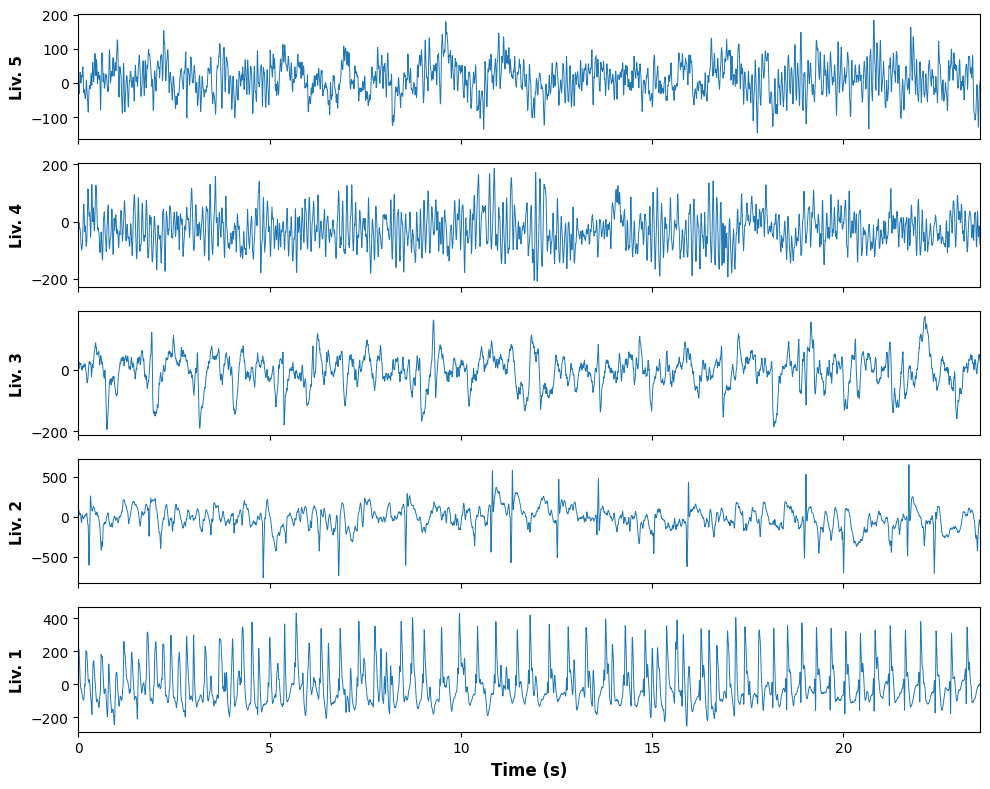

In [3]:
# Mostriamo un segnale campione per ogni livello
i = 11
row1 = df1.iloc[i]
row2 = df2.iloc[i]
row3 = df3.iloc[i]
row4 = df4.iloc[i]
row5 = df5.iloc[i]

fs = 173.61 # Frequenza dei segnali
campioni_1_sec = int(round(fs)) 

tempi = np.arange(len(row1)) / fs

fig, axes = plt.subplots(5, 1, figsize=(10, 8), sharex=True)

segnali = [row5, row4, row3, row2, row1]
etichette = ['Liv. 5', 'Liv. 4', 'Liv. 3', 'Liv. 2', 'Liv. 1']

for i in range(5):
    axes[i].plot(tempi, segnali[i], linewidth=0.7)
    
    axes[i].set_ylabel(etichette[i], fontsize=11, fontweight='bold')
    
axes[4].set_xlabel("Time (s)", fontsize=12, fontweight='bold')
axes[4].set_xlim(0, max(tempi))

plt.tight_layout()
plt.show()

## 2 - Studio dei pazienti di rilievo con e senza outliers

In [4]:
# Importiamo le librerie necessarie
from sklearn.preprocessing import StandardScaler
from sklearn import svm, datasets

In [5]:
# Normalizzazione dei dataset
scaler = StandardScaler()

scale2 = pd.DataFrame(scaler.fit_transform(df2), columns=df2.columns, index=df2.index)
scale3 = pd.DataFrame(scaler.fit_transform(df3), columns=df3.columns, index=df3.index)

### 2.1-Ricerca degli outliers

Sfruttando la normalizzazione del dataset df2 e df3, cerchiamo di identificare eventuali pazienti che presentano segnali atipici rispetto alla media del dataset di riferimento.

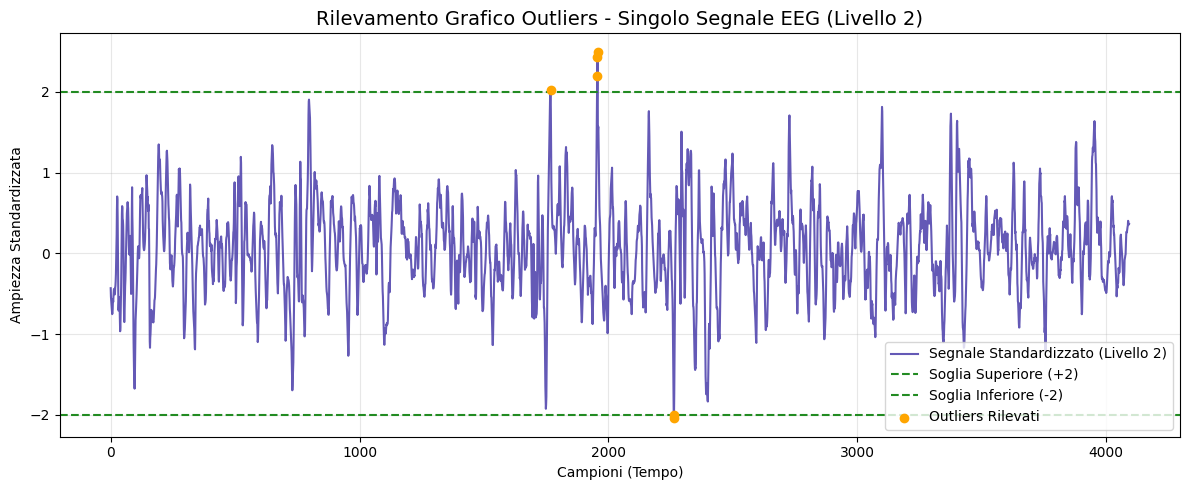

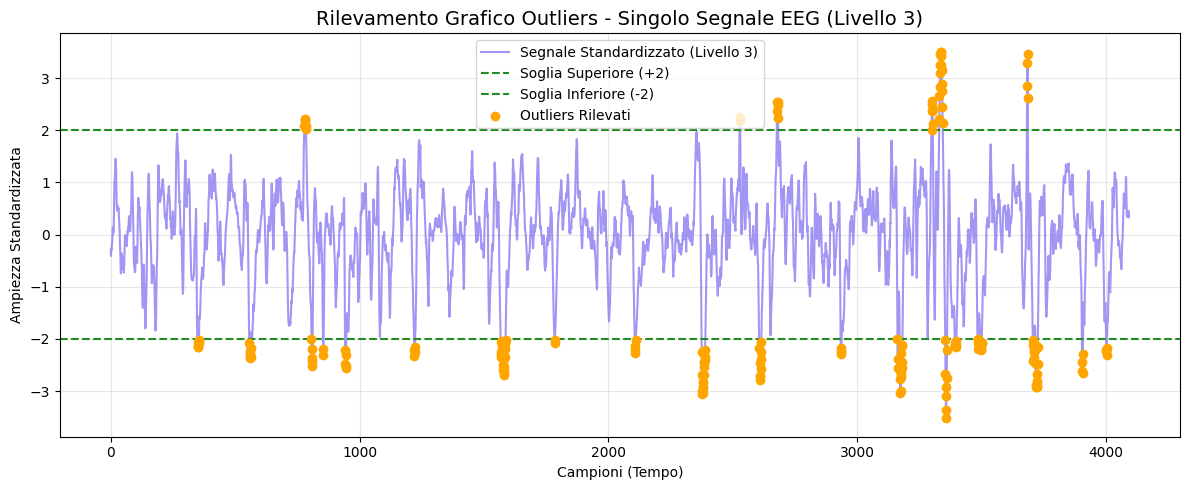

In [6]:
# Plot grafico con outliers
soglia = 2 # 2 volte la std

# Plot per un segnale test di Livello 2
segnale_test_2 = scale2.iloc[2].values

plt.figure(figsize=(12, 5))
plt.plot(segnale_test_2, label="Segnale Standardizzato (Livello 2)", color="#3d30a4", alpha=0.8)

# Linee di soglia
plt.axhline(y=soglia, color='forestgreen', linestyle='--', label=f'Soglia Superiore (+{soglia})')
plt.axhline(y=-soglia, color='forestgreen', linestyle='--', label=f'Soglia Inferiore (-{soglia})')

# Troviamo e plottiamo i pallini rossi
x_out_2 = np.where(np.abs(segnale_test_2) > soglia)[0]
y_out_2 = segnale_test_2[x_out_2]
plt.scatter(x_out_2, y_out_2, color='orange', zorder=5, label='Outliers Rilevati')

plt.title("Rilevamento Grafico Outliers - Singolo Segnale EEG (Livello 2)", fontsize=14)
plt.xlabel("Campioni (Tempo)"); plt.ylabel("Ampiezza Standardizzata")
plt.legend(loc='best'); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot per un segnale di Livello 3
segnale_test_3 = scale3.iloc[2].values

plt.figure(figsize=(12, 5))
plt.plot(segnale_test_3, label="Segnale Standardizzato (Livello 3)", color='#8a7cf1', alpha=0.8)

# Linee di soglia
plt.axhline(y=soglia, color='forestgreen', linestyle='--', label=f'Soglia Superiore (+{soglia})')
plt.axhline(y=-soglia, color='forestgreen', linestyle='--', label=f'Soglia Inferiore (-{soglia})')

# Troviamo e plottiamo i pallini rossi
x_out_3 = np.where(np.abs(segnale_test_3) > soglia)[0]
y_out_3 = segnale_test_3[x_out_3]
plt.scatter(x_out_3, y_out_3, color='orange', zorder=5, label='Outliers Rilevati')

plt.title("Rilevamento Grafico Outliers - Singolo Segnale EEG (Livello 3)", fontsize=14)
plt.xlabel("Campioni (Tempo)"); plt.ylabel("Ampiezza Standardizzata")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# RICERCA OUTLIERS
def ricerca_outlier(df, valore_soglia):
    matrice_is_outlier = abs(df) > valore_soglia
    conta_outlier = matrice_is_outlier.sum(axis=1)
    return conta_outlier / df.shape[1] * 100

# --- TABELLE ANALISI OUTLIERS ---
valori_soglia = [1, 1.5, 2, 2.5, 3]
perc_max_anomalie = [10, 20, 30, 40, 50, 60, 70, 80, 90]

print("\t\tTabella numero outlier per Livello 2: ")
print("Val.soglia", end='\t')
for p in perc_max_anomalie:
    print(f"{p}%", end='\t')
print()
for v in valori_soglia:
    print(v, end='\t\t')
    conta_outlier_perc = ricerca_outlier(scale2, v)
    for p in perc_max_anomalie:
        # Conto il numero di righe che superano la % massima di anomalie
        count = (conta_outlier_perc >= p).sum()
        print(count, end='\t')
    print()

print("\n\t\tTabella numero outlier per Livello 3: ")
print("Val.soglia", end='\t')
for p in perc_max_anomalie:
    print(f"{p}%", end='\t')
print()
for v in valori_soglia:
    print(v, end='\t\t')
    conta_outlier_perc = ricerca_outlier(scale3, v)
    for p in perc_max_anomalie:
        # Conto il numero di righe che superano la % massima di anomalie
        count = (conta_outlier_perc >= p).sum()
        print(count, end='\t')
    print()
print("\n" + "="*50 + "\n")

		Tabella numero outlier per Livello 2: 
Val.soglia	10%	20%	30%	40%	50%	60%	70%	80%	90%	
1		63	40	21	8	6	4	3	1	0	
1.5		26	11	7	4	3	2	1	0	0	
2		13	5	4	2	2	2	0	0	0	
2.5		6	4	2	2	1	0	0	0	0	
3		5	2	2	1	0	0	0	0	0	

		Tabella numero outlier per Livello 3: 
Val.soglia	10%	20%	30%	40%	50%	60%	70%	80%	90%	
1		83	65	44	17	7	2	0	0	0	
1.5		52	16	5	1	0	0	0	0	0	
2		12	4	1	0	0	0	0	0	0	
2.5		4	1	0	0	0	0	0	0	0	
3		2	0	0	0	0	0	0	0	0	




### 2.2 - Studio dei dataset con e senza outliers
Fissiamo una soglia di $2*\sigma$ e consideriamo i segnali outliers quelli che hanno una percentuale di misurazioni outliers maggiore o uguale al 30%. Non conoscendo la rilevanza dei segnali outliers all'interno dello studio del dataset, analizzeremo i dataset sia con sia senza segnali outliers.

In [8]:
# Importiamo le librerie necessarie
import seaborn as sns
from sklearn.metrics import accuracy_score, roc_curve, auc, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

In [9]:
# Cerchiamo gli indici degli outliers e li rimuoviamo dal dataset
perc_toll = 30

idx2_no_out = ricerca_outlier(scale2, soglia) > perc_toll
idx3_no_out = ricerca_outlier(scale3, soglia) > perc_toll

# Dati originali puliti dagli outliers
df2_no_out_raw = df2[~idx2_no_out].copy()
df3_no_out_raw = df3[~idx3_no_out].copy()

# Aggiungiamo le etichette y ai dati originali
df2_labeled = df2.copy(); df2_labeled['y'] = 2
df3_labeled = df3.copy(); df3_labeled['y'] = 3

df2_no_out_raw['y'] = 2
df3_no_out_raw['y'] = 3

# DATASET 1: CON OUTLIERS
train_out_raw = pd.concat([df2_labeled.iloc[:80], df3_labeled.iloc[:80]])
test_out_raw = pd.concat([df2_labeled.iloc[80:], df3_labeled.iloc[80:]])

X_train_out_raw = train_out_raw.drop(columns=['y'])
y_train_out = train_out_raw['y']
X_test_out_raw = test_out_raw.drop(columns=['y'])
y_test_out = test_out_raw['y']

# Normalizzazione
X_train_out = pd.DataFrame(scaler.fit_transform(X_train_out_raw), columns=X_train_out_raw.columns, index=X_train_out_raw.index)
X_test_out = pd.DataFrame(scaler.transform(X_test_out_raw), columns=X_test_out_raw.columns, index=X_test_out_raw.index)

# DATASET 2: SENZA OUTLIERS
train_no_out_raw = pd.concat([df2_no_out_raw.iloc[:80], df3_no_out_raw.iloc[:80]])
test_no_out_raw = pd.concat([df2_no_out_raw.iloc[80:], df3_no_out_raw.iloc[80:]])

X_train_no_raw = train_no_out_raw.drop(columns=['y'])
y_train_no = train_no_out_raw['y']
X_test_no_raw = test_no_out_raw.drop(columns=['y'])
y_test_no = test_no_out_raw['y']

# Normalizzazione
X_train_no = pd.DataFrame(scaler.fit_transform(X_train_no_raw), columns=X_train_no_raw.columns, index=X_train_no_raw.index)
X_test_no = pd.DataFrame(scaler.transform(X_test_no_raw), columns=X_test_no_raw.columns, index=X_test_no_raw.index)

datasets = {
    'Con Outliers': (X_train_out, y_train_out, X_test_out, y_test_out),
    'Senza Outliers': (X_train_no, y_train_no, X_test_no, y_test_no)
}

>>> ADDESTRAMENTO REGRESSIONE LOGISTICA (BASELINE) <<<
 - Con Outliers   : Accuratezza = 0.9000 | AUC = 0.9350
 - Senza Outliers : Accuratezza = 0.8571 | AUC = 0.9342


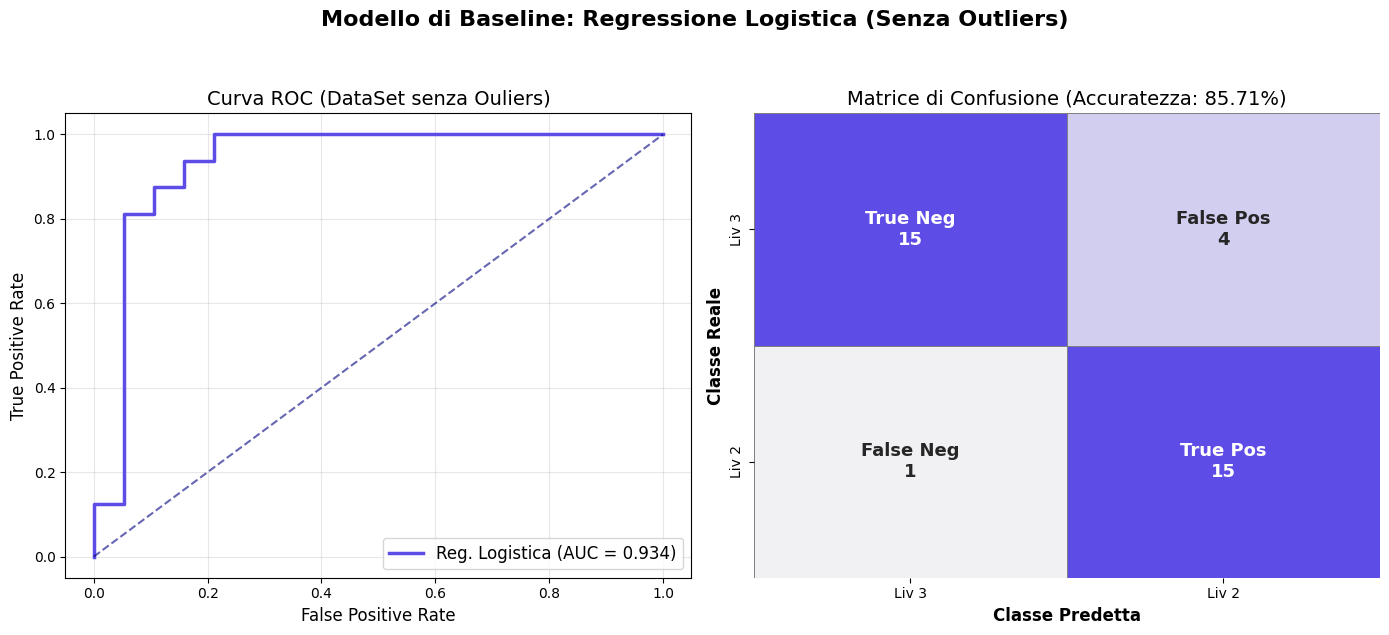

In [10]:
# BASELINE MODEL: REGRESSIONE LOGISTICA

from sklearn.linear_model import LogisticRegression

mio_viola = sns.light_palette("#5e4ce6", as_cmap=True)

print(">>> ADDESTRAMENTO REGRESSIONE LOGISTICA (BASELINE) <<<")

results_lr = {}

# Alleniamo e testiamo il modello su entrambi i dataset
for ds_name, (X_train, y_train, X_test, y_test) in datasets.items():
    lr = LogisticRegression(random_state=11, max_iter=1000)
    lr.fit(X_train, y_train)
    
    y_pred = lr.predict(X_test)
    
    y_score = lr.predict_proba(X_test)[:, 0] 
    
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred, labels=[3, 2])
    
    fpr_roc, tpr_roc, _ = roc_curve(y_test, y_score, pos_label=2)
    roc_auc = auc(fpr_roc, tpr_roc)
    
    results_lr[ds_name] = {
        'model': lr, 'acc': acc, 'cm': cm, 
        'fpr_roc': fpr_roc, 'tpr_roc': tpr_roc, 'auc': roc_auc
    }
    print(f" - {ds_name:<15}: Accuratezza = {acc:.4f} | AUC = {roc_auc:.4f}")

# PLOT UNIFICATO (Focalizzato sul dataset "Senza Outliers")
res = results_lr['Senza Outliers']
cm_lr = res['cm']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Modello di Baseline: Regressione Logistica (Senza Outliers)', 
             fontsize=16, fontweight='bold', y=1.05)

# --- SUBPLOT 1: CURVA ROC ---
ax1 = axes[0]
ax1.plot(res['fpr_roc'], res['tpr_roc'], color='#5e4ce6', linewidth=2.5, 
         label=f"Reg. Logistica (AUC = {res['auc']:.3f})")
ax1.plot([0, 1], [0, 1], color='navy', linestyle='--', alpha=0.6)

ax1.set_title('Curva ROC (DataSet senza Ouliers)', fontsize=14)
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.legend(loc="lower right", fontsize=12)
ax1.grid(alpha=0.3)

# --- SUBPLOT 2: CONFUSION MATRIX ---
ax2 = axes[1]
labels = np.asarray([f"True Neg\n{cm_lr[0,0]}", f"False Pos\n{cm_lr[0,1]}",
                     f"False Neg\n{cm_lr[1,0]}", f"True Pos\n{cm_lr[1,1]}"]).reshape(2,2)

# Se hai già 'mio_viola' in memoria puoi usare cmap=mio_viola
sns.heatmap(cm_lr, annot=labels, fmt='', cmap=mio_viola, cbar=False, ax=ax2,
            xticklabels=['Liv 3', 'Liv 2'], 
            yticklabels=['Liv 3', 'Liv 2'],
            annot_kws={"size": 13, "fontweight": "bold"}, linewidths=0.5, linecolor='grey')

ax2.set_title(f"Matrice di Confusione (Accuratezza: {res['acc']:.2%})", fontsize=14)
ax2.set_ylabel('Classe Reale', fontweight='bold', fontsize=12)
ax2.set_xlabel('Classe Predetta', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

Per lo studio preliminare non abbiamo usato parametri casuali, ma avendo molte feature (i singoli istanti di campionamento dell'EEG), la teoria delle SVM suggerisce che un kernel Lineare con un parametro C standard (=1) va in overfitting istantaneo. Quindi, abbiamo impostato un C molto basso (0.001) come punto di partenza 'ragionevole' per avere una baseline sensata, lasciando poi alla GridSearch il compito di esplorare rigorosamente lo spazio dei parametri.

In [11]:
# STUDIO PRELIMINARE: Confronto dei Kernel SVM (Linear, Poly, RBF)

results_plot = {'Con Outliers': {}, 'Senza Outliers': {}}

for ds_name, (X_train, y_train, X_test, y_test) in datasets.items():
    models_pre = {
        'Linear': svm.SVC(kernel='linear', C=0.001, random_state=11),
        'Poly': svm.SVC(kernel='poly', degree=3, C=5, gamma='scale', random_state=11),
        'RBF': svm.SVC(kernel='rbf', C=5, gamma='scale', random_state=11)
    }
    
    for model_name, clf in models_pre.items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        y_score = clf.decision_function(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred, labels=[3, 2])
        
        tn, fp, fn, tp = cm.ravel()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
        
        # Consideriamo il Livello 3 come classe positiva
        fpr_roc, tpr_roc, _ = roc_curve(y_test, -y_score, pos_label=2)
        roc_auc = auc(fpr_roc, tpr_roc)
        
        results_plot[ds_name][model_name] = {
            'acc': acc, 'cm': cm, 'tpr': tpr, 'tnr': tnr, 
            'fpr_roc': fpr_roc, 'tpr_roc': tpr_roc, 'auc': roc_auc
        }

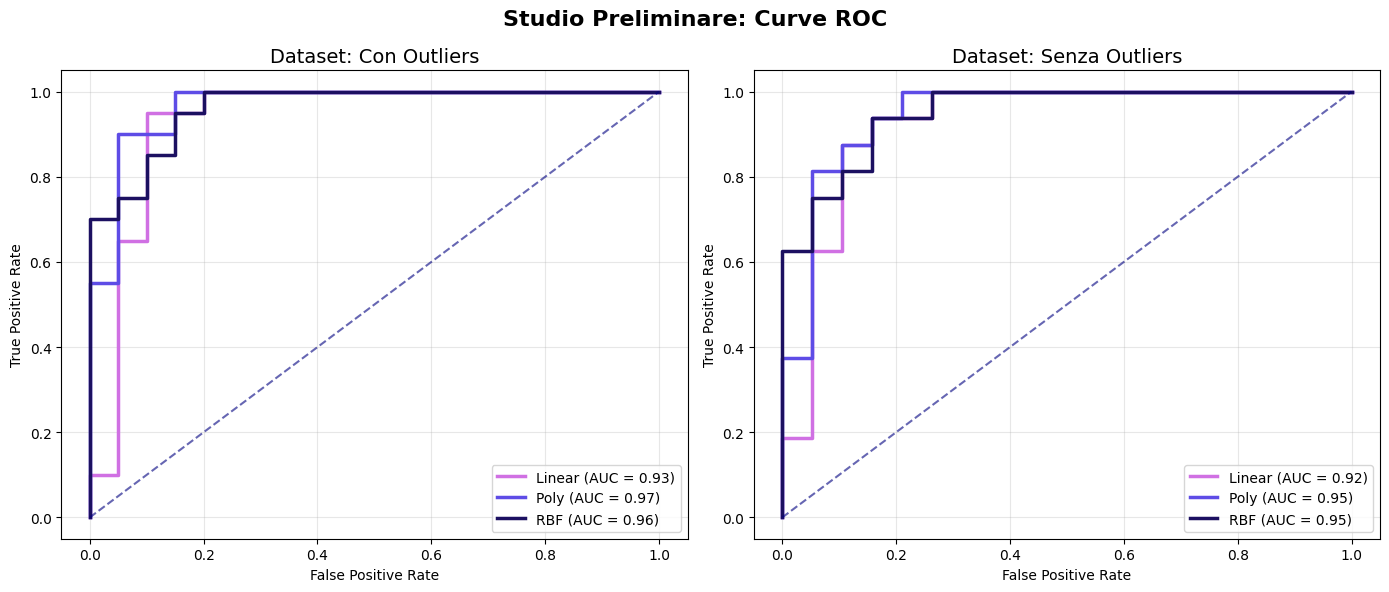

In [12]:
# PLOT 1: ROC CURVES
colori_modelli = {
    'Linear': '#d070e3',  # Un lilla/magenta acceso
    'Poly': '#5e4ce6',    # Il tuo viola/pervinca personalizzato
    'RBF': '#1c1061'      # Un blu/viola scurissimo per dare contrasto
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Studio Preliminare: Curve ROC', fontsize=16, fontweight='bold')

for i, ds_name in enumerate(datasets.keys()):
    ax = axes[i]
    for model_name in models_pre.keys():
        res = results_plot[ds_name][model_name]
        ax.plot(res['fpr_roc'], res['tpr_roc'], linewidth=2.5,
                color=colori_modelli[model_name], label=f"{model_name} (AUC = {res['auc']:.2f})")
        
    ax.plot([0, 1], [0, 1], color='navy', linestyle='--', alpha=0.6)
    ax.set_title(f'Dataset: {ds_name}', fontsize=14); ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

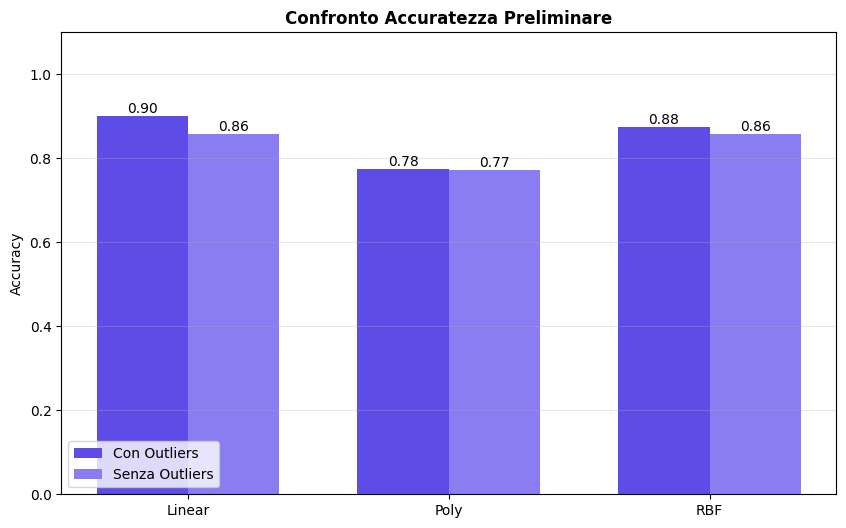

In [13]:
# PLOT 2: ACCURATEZZE A BARRE
acc_outliers = [results_plot['Con Outliers'][m]['acc'] for m in models_pre.keys()]
acc_no_outliers = [results_plot['Senza Outliers'][m]['acc'] for m in models_pre.keys()]

x = np.arange(len(models_pre)); width = 0.35 
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, acc_outliers, width, label='Con Outliers', color='#5e4ce6')
ax.bar(x + width/2, acc_no_outliers, width, label='Senza Outliers', color="#8a7cf1")

ax.set_ylabel('Accuracy'); ax.set_title('Confronto Accuratezza Preliminare', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(models_pre.keys())
ax.legend(loc='lower left'); ax.set_ylim(0, 1.1)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.grid(axis='y', alpha=0.3)
plt.show()

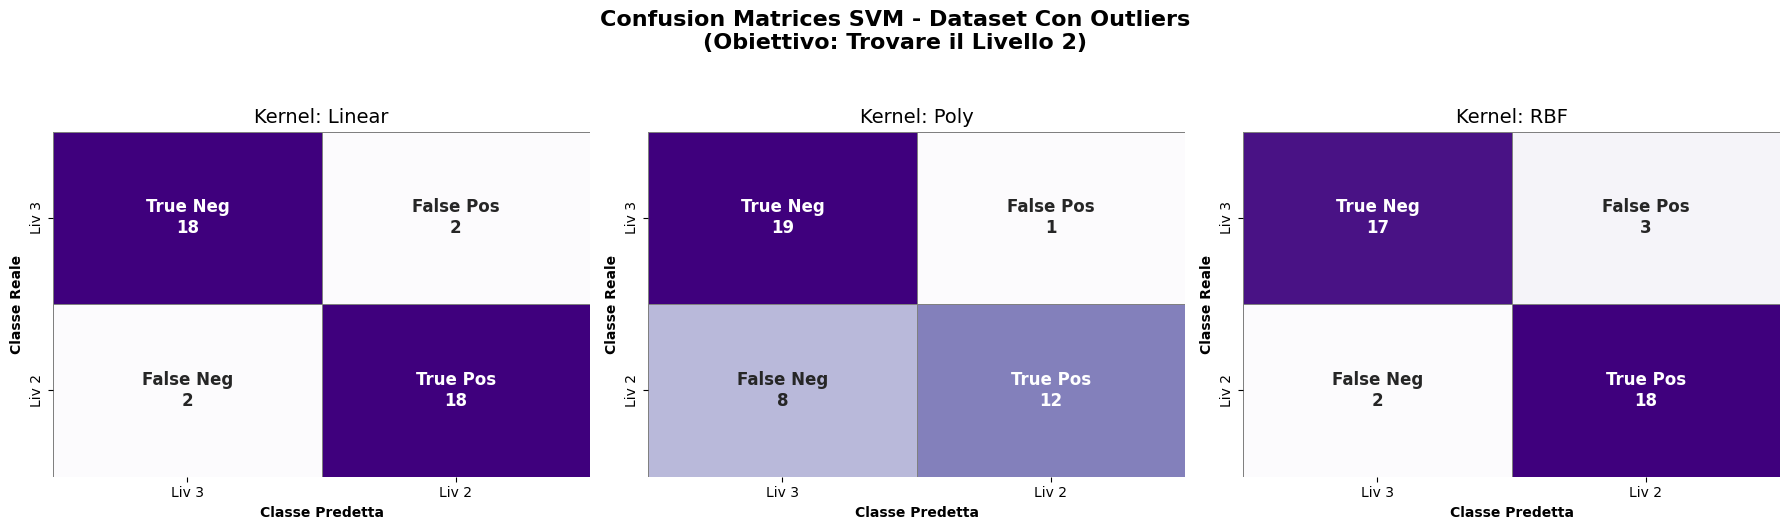

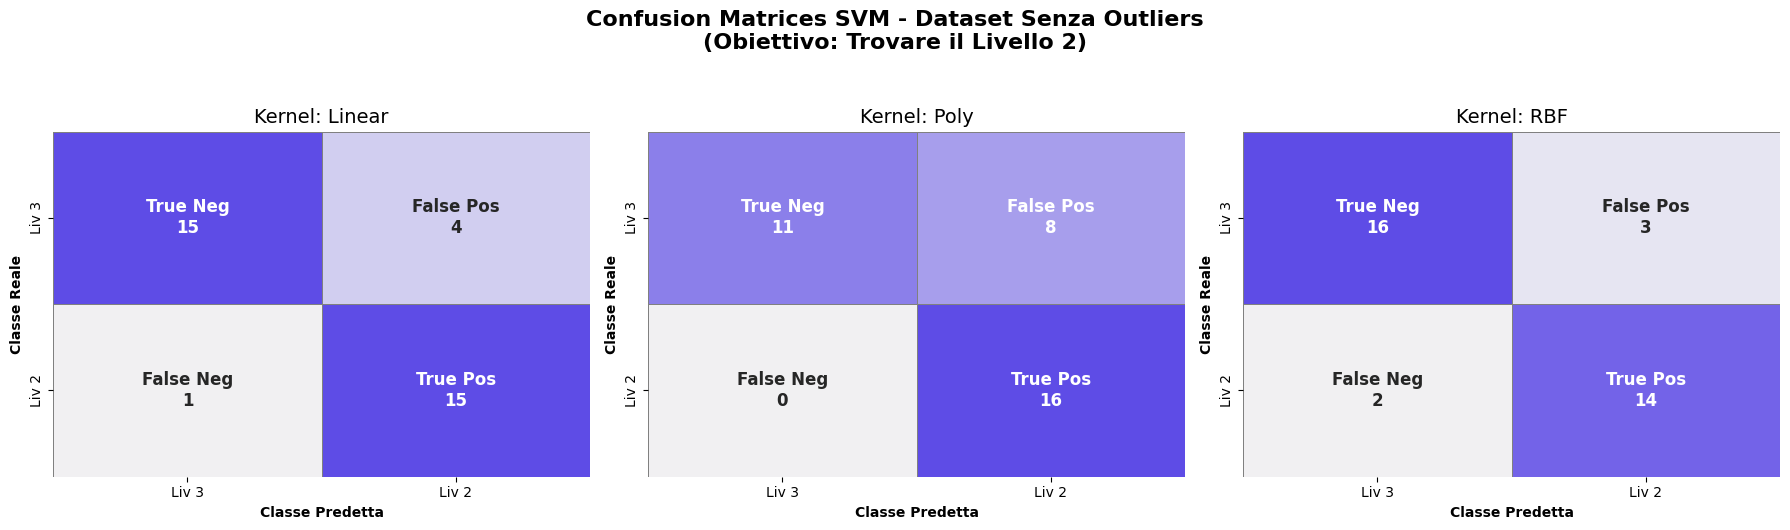

In [14]:
# PLOT 3: CONFUSION MATRICES
mio_viola = sns.light_palette("#5e4ce6", as_cmap=True)

for ds_name, color_map in zip(['Con Outliers', 'Senza Outliers'], ['Purples', mio_viola]):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Confusion Matrices SVM - Dataset {ds_name}\n(Obiettivo: Trovare il Livello 2)', 
                 fontsize=16, y=1.05, fontweight='bold')
    
    for j, model_name in enumerate(models_pre.keys()):
        ax = axes[j]
        cm = results_plot[ds_name][model_name]['cm']
        
        labels = np.asarray([f"True Neg\n{cm[0,0]}", f"False Pos\n{cm[0,1]}",
                             f"False Neg\n{cm[1,0]}", f"True Pos\n{cm[1,1]}"]).reshape(2,2)
        
        sns.heatmap(cm, annot=labels, fmt='', cmap=color_map, cbar=False, ax=ax,
                    xticklabels=['Liv 3', 'Liv 2'], 
                    yticklabels=['Liv 3', 'Liv 2'],
                    annot_kws={"size": 12, "fontweight": "bold"}, linewidths=0.5, linecolor='grey')
        
        ax.set_title(f"Kernel: {model_name}", fontsize=14)
        ax.set_ylabel('Classe Reale', fontweight='bold')
        ax.set_xlabel('Classe Predetta', fontweight='bold')
        
    plt.tight_layout()
    plt.show()

## 3 - GridsearchCV dei parametri

Dallo studio preliminare notiamo che il modello con kernel lineare sembra non riuscire a separare bene le due classi come i modelli con kernel Poly o RBF. Di conseguenza, effettuiamo una GridSearchCV, sia per la SVM sia per RandomForest, per vedere se questo comportamento derivi dai parametri scelti o da una caratteristica strutturale di un kernel lineare.

Effettueremo anche una k_fold Validation per capire se i risultati ottenuti siano statisticamente significativi.

Inoltre, aggiungeremo anche uno studio dei dataset con RandomForest analizzando in modo analogo alla SVM l'impatto del cambiamento dei parametri all'interno di una k_fold Validation.

Come metrica decisionale abbiamo scelto scoring = 'roc_auc' perché tiene conto anche della confidenza di classificazione e non solo correttezza della stessa.

In [15]:
# CROSS VALIDATION: SVM E RANDOM FOREST SU ENTRAMBI I DATASET
cv_folds = [5, 7, 9]

param_grid_svm = [
    {'kernel': ['linear'], 'C': [0.001, 0.1, 1, 5, 10]},
    {'kernel': ['poly'], 'C': [0.01, 0.1, 1, 5, 10], 'degree': [2, 3], 'gamma': ['scale', 0.1]},
    {'kernel': ['rbf'], 'C': [0.01, 0.1, 1, 5, 10], 'gamma': ['scale', 0.1, 0.01, 0.001]}
]

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 3, 5, 8],
    'min_samples_split': [2, 5, 10]
}

results = {'Con Outliers': {}, 'Senza Outliers': {}}
best_models = {}

for ds_name, (X_tr, y_tr, X_te, y_te) in datasets.items():
    print(f"\n{'='*70}")
    print(f" ANALISI DATASET: {ds_name.upper()} ")
    print(f"{'='*70}")
    
    # Salviamo l'intera "Grid" vincente
    best_svm_grid = None; best_rf_grid = None
    best_svm_fold = 0; best_rf_fold = 0
    
    for folds in cv_folds:
        cv_strategy = StratifiedKFold(n_splits=folds, shuffle=True, random_state=11)
        
        # Ottimizzazione SVM
        grid_svm = GridSearchCV(svm.SVC(probability=True, random_state=11), param_grid_svm, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
        grid_svm.fit(X_tr, y_tr)
        
        # Salviamo la grid migliore
        if best_svm_grid is None or grid_svm.best_score_ > best_svm_grid.best_score_:
            best_svm_grid = grid_svm
            best_svm_fold = folds
            
        # Ottimizzazione Random Forest
        grid_rf = GridSearchCV(RandomForestClassifier(random_state=11), param_grid_rf, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
        grid_rf.fit(X_tr, y_tr)
        
        # Salviamo la grid migliore
        if best_rf_grid is None or grid_rf.best_score_ > best_rf_grid.best_score_:
            best_rf_grid = grid_rf
            best_rf_fold = folds
            
    # Salviamo i modelli estratti dalle grid vincenti
    best_models[ds_name] = {'SVM': best_svm_grid.best_estimator_, 'RandomForest': best_rf_grid.best_estimator_}
    
    # STAMPA A VIDEO DELLA "TOP 3"
    print(f"\n>>> RISULTATI CROSS-VALIDATION SVM (Miglior fold: {best_svm_fold}) <<<")
    means = best_svm_grid.cv_results_['mean_test_score']
    stds = best_svm_grid.cv_results_['std_test_score']
    params = best_svm_grid.cv_results_['params']
    
    # Ordiniamo gli indici dal risultato migliore al peggiore e prendiamo i primi 3
    sorted_idx = means.argsort()[::-1][:3]
    for rank, i in enumerate(sorted_idx, 1):
        print(f" {rank}° Posto | AUC Media: {means[i]:.4f} (±{stds[i]:.4f}) | Parametri: {params[i]}")

    print(f"\n>>> RISULTATI CROSS-VALIDATION RANDOM FOREST (Miglior fold: {best_rf_fold}) <<<")
    means_rf = best_rf_grid.cv_results_['mean_test_score']
    stds_rf = best_rf_grid.cv_results_['std_test_score']
    params_rf = best_rf_grid.cv_results_['params']
    
    sorted_idx_rf = means_rf.argsort()[::-1][:3]
    for rank, i in enumerate(sorted_idx_rf, 1):
        print(f" {rank}° Posto | AUC Media: {means_rf[i]:.4f} (±{stds_rf[i]:.4f}) | Parametri: {params_rf[i]}")
    
    # VALUTAZIONE FINALE SUL TEST SET
    print("\n>>> PERFORMANCE SUL TEST SET <<<")
    for model_name, model in best_models[ds_name].items():
        y_pred = model.predict(X_te)
        
        # GESTIONE DIFFERENZIATA DEGLI SCORE PER SVM E RANDOM FOREST
        if model_name == 'SVM':
            y_score = model.decision_function(X_te)
            fpr_roc, tpr_roc, _ = roc_curve(y_te, -y_score, pos_label=2)
        else:
            # La Random Forest usa probabilità. model.classes_ è [2, 3].
            # Quindi la colonna 0 è la probabilità esatta di essere Livello 2! Niente segno meno.
            y_score = model.predict_proba(X_te)[:, 0]
            fpr_roc, tpr_roc, _ = roc_curve(y_te, y_score, pos_label=2)
            
        roc_auc = auc(fpr_roc, tpr_roc)
        acc = accuracy_score(y_te, y_pred)
        
        results[ds_name][model_name] = {
            'acc': acc, 'fpr_roc': fpr_roc, 'tpr_roc': tpr_roc, 'auc': roc_auc,
            'report': classification_report(y_te, y_pred)
        }
        print(f" - {model_name:<15}: Accuratezza = {acc:.4f} | AUC = {roc_auc:.4f}")


 ANALISI DATASET: CON OUTLIERS 

>>> RISULTATI CROSS-VALIDATION SVM (Miglior fold: 9) <<<
 1° Posto | AUC Media: 0.9607 (±0.0338) | Parametri: {'C': 5, 'gamma': 'scale', 'kernel': 'rbf'}
 2° Posto | AUC Media: 0.9564 (±0.0360) | Parametri: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
 3° Posto | AUC Media: 0.9472 (±0.0584) | Parametri: {'C': 0.001, 'kernel': 'linear'}

>>> RISULTATI CROSS-VALIDATION RANDOM FOREST (Miglior fold: 9) <<<
 1° Posto | AUC Media: 0.9475 (±0.0452) | Parametri: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 300}
 2° Posto | AUC Media: 0.9456 (±0.0308) | Parametri: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
 3° Posto | AUC Media: 0.9443 (±0.0314) | Parametri: {'max_depth': 8, 'min_samples_split': 2, 'n_estimators': 300}

>>> PERFORMANCE SUL TEST SET <<<
 - SVM            : Accuratezza = 0.8750 | AUC = 0.9625
 - RandomForest   : Accuratezza = 0.9000 | AUC = 0.9575

 ANALISI DATASET: SENZA OUTLIERS 

>>> RISULTATI CROSS-VALIDATION

In [16]:
# STAMPA DEL REPORT FINALE PER IL DATASET SENZA OUTLIERS
print("\n" + "="*50)
print(" REPORT CLASSIFICAZIONE FINALE (Senza Outliers) ")
print("="*50)
print("\n--- Support Vector Machine ---")
print(results['Senza Outliers']['SVM']['report'])
print("\n--- Random Forest ---")
print(results['Senza Outliers']['RandomForest']['report'])


 REPORT CLASSIFICAZIONE FINALE (Senza Outliers) 

--- Support Vector Machine ---
              precision    recall  f1-score   support

           2       0.82      0.88      0.85        16
           3       0.89      0.84      0.86        19

    accuracy                           0.86        35
   macro avg       0.86      0.86      0.86        35
weighted avg       0.86      0.86      0.86        35


--- Random Forest ---
              precision    recall  f1-score   support

           2       0.88      0.88      0.88        16
           3       0.89      0.89      0.89        19

    accuracy                           0.89        35
   macro avg       0.88      0.88      0.88        35
weighted avg       0.89      0.89      0.89        35



### 3.1 - Grafici comparativi

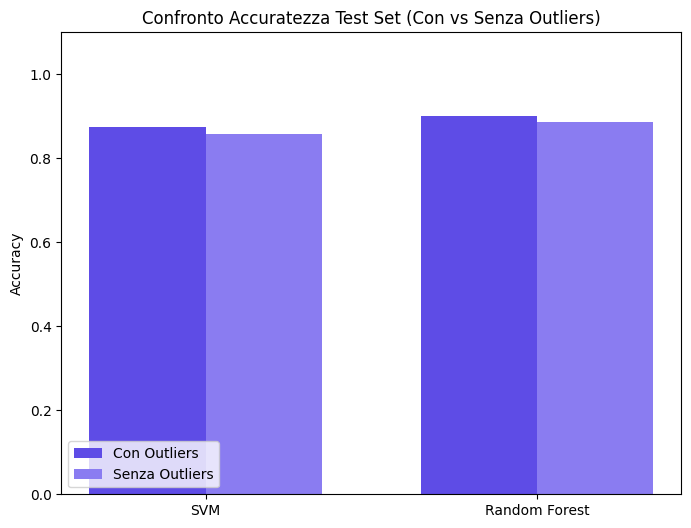

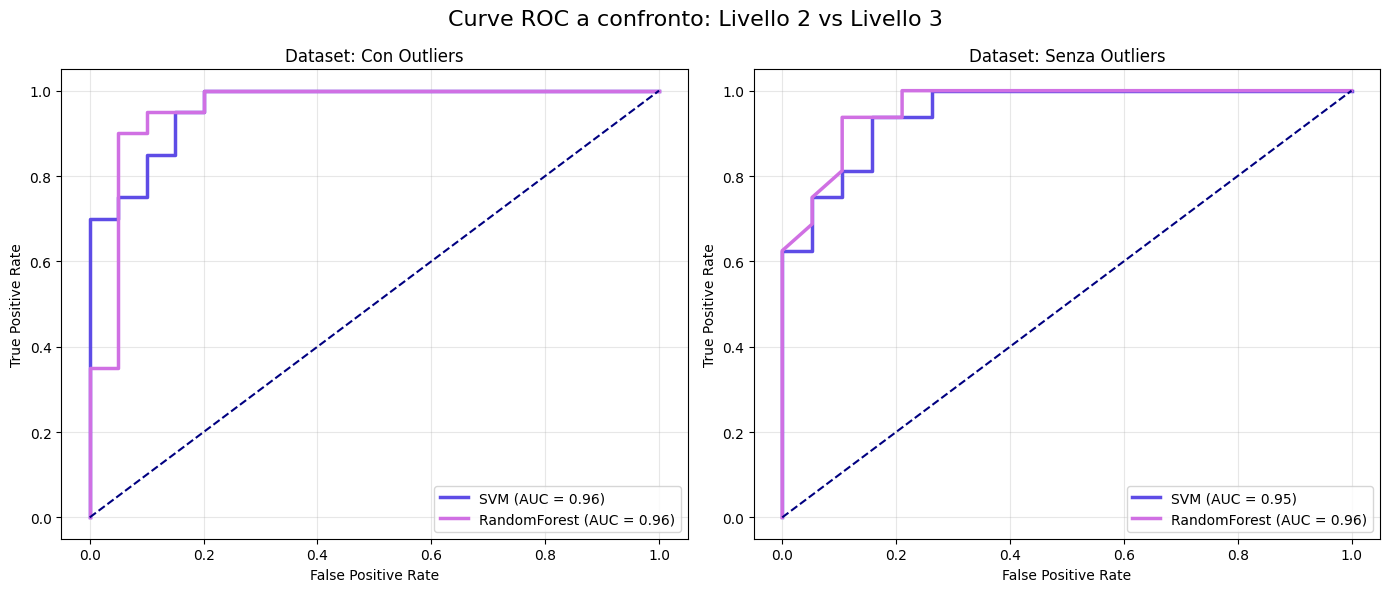

In [17]:
# PLOT GRAFICI COMPARATIVI (Accuratezza)
acc_out = [results['Con Outliers'][m]['acc'] for m in ['SVM', 'RandomForest']]
acc_no_out = [results['Senza Outliers'][m]['acc'] for m in ['SVM', 'RandomForest']]

fig, ax = plt.subplots(figsize=(8, 6))
width = 0.35; x = np.arange(2)
ax.bar(x - width/2, acc_out, width, label='Con Outliers', color='#5e4ce6')
ax.bar(x + width/2, acc_no_out, width, label='Senza Outliers', color='#8a7cf1')
ax.set_ylabel('Accuracy'); ax.set_title('Confronto Accuratezza Test Set (Con vs Senza Outliers)')
ax.set_xticks(x); ax.set_xticklabels(['SVM', 'Random Forest'])
ax.legend(loc='lower left')
ax.set_ylim(0, 1.1)
plt.show()

# Curve ROC 
colori_modelli_finali = {
    'SVM': '#5e4ce6',           # Il tuo viola principale
    'RandomForest': '#d070e3'   # Un lilla/magenta per farla risaltare
}
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Curve ROC a confronto: Livello 2 vs Livello 3', fontsize=16)

for i, ds_name in enumerate(datasets.keys()):
    ax = axes[i]
    for model_name in ['SVM', 'RandomForest']:
        res = results[ds_name][model_name]
        ax.plot(res['fpr_roc'], res['tpr_roc'],linewidth=2.5,
                color=colori_modelli_finali[model_name], label=f"{model_name} (AUC = {res['auc']:.2f})")
    
    ax.plot([0, 1], [0, 1], color='navy', linestyle='--')
    ax.set_title(f'Dataset: {ds_name}')
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.legend(loc="lower right"); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
y_pred = miglior_svm.predict(X_test_no)
y_pred

array([3, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3,
       3, 2, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 2])

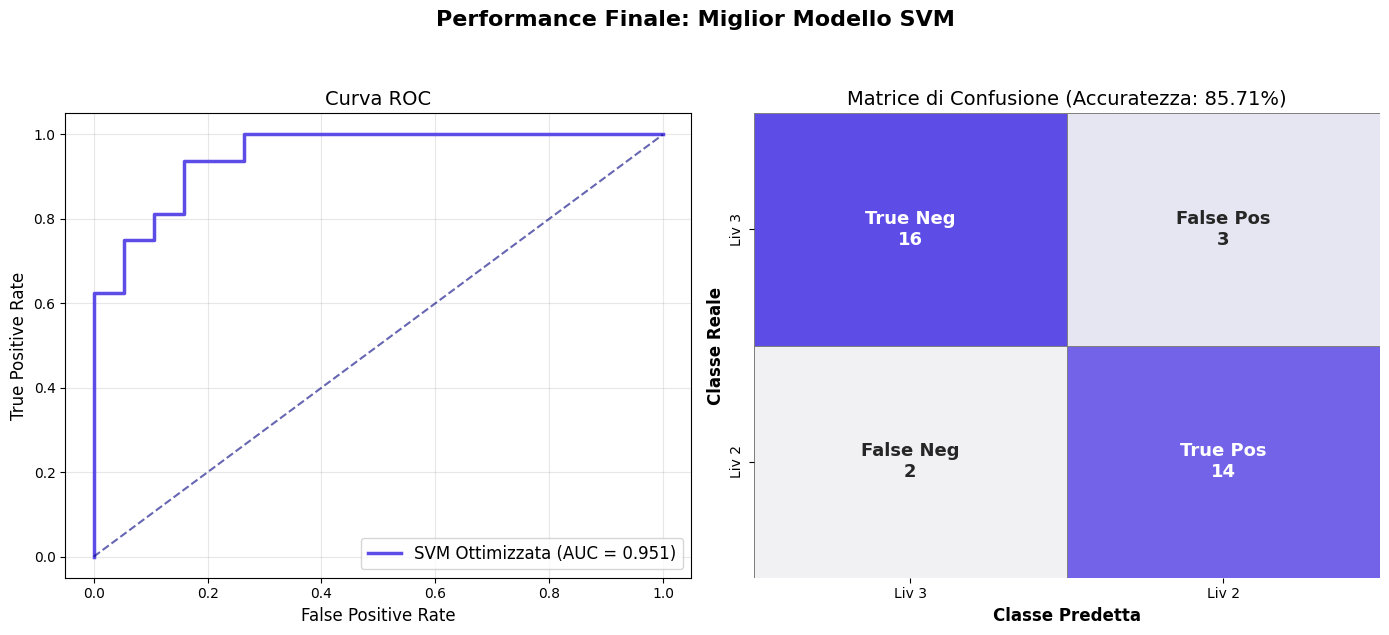

In [18]:
# RAPPRESENTAZIONE GRAFICA DELLA SVM (Senza Outliers)

miglior_svm = best_models['Senza Outliers']['SVM']

y_pred = miglior_svm.predict(X_test_no)
y_score = miglior_svm.decision_function(X_test_no)

acc = accuracy_score(y_test_no, y_pred)
cm = confusion_matrix(y_test_no, y_pred, labels=[3, 2])

tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
tnr = tn / (tn + fp) if (tn + fp) > 0 else 0

# Consideriamo il Livello 3 come classe positiva
fpr_roc, tpr_roc, _ = roc_curve(y_test_no, -y_score, pos_label=2)
roc_auc = auc(fpr_roc, tpr_roc)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Performance Finale: Miglior Modello SVM', fontsize=16, fontweight='bold', y=1.05)

# SUBPLOT 1: ROC CURVE
ax1 = axes[0]
ax1.plot(fpr_roc, tpr_roc, color='#5e4ce6', linewidth=2.5, label=f"SVM Ottimizzata (AUC = {roc_auc:.3f})")
ax1.plot([0, 1], [0, 1], color='navy', linestyle='--', alpha=0.6)

ax1.set_title('Curva ROC', fontsize=14)
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.legend(loc="lower right", fontsize=12)
ax1.grid(alpha=0.3)

# SUBPLOT 2: CONFUSION MATRIX
ax2 = axes[1]
# Creiamo le etichette di testo da mettere dentro i quadratini
labels = np.asarray([f"True Neg\n{cm[0,0]}", f"False Pos\n{cm[0,1]}",
                     f"False Neg\n{cm[1,0]}", f"True Pos\n{cm[1,1]}"]).reshape(2,2)

sns.heatmap(cm, annot=labels, fmt='', cmap=mio_viola, cbar=False, ax=ax2,
            xticklabels=['Liv 3', 'Liv 2'], 
            yticklabels=['Liv 3', 'Liv 2'],
            annot_kws={"size": 13, "fontweight": "bold"}, linewidths=0.5, linecolor='grey')

# Inseriamo l'accuratezza direttamente nel titolo della matrice per un colpo d'occhio immediato
ax2.set_title(f"Matrice di Confusione (Accuratezza: {acc:.2%})", fontsize=14)
ax2.set_ylabel('Classe Reale', fontweight='bold', fontsize=12)
ax2.set_xlabel('Classe Predetta', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

<Figure size 2200x1200 with 0 Axes>

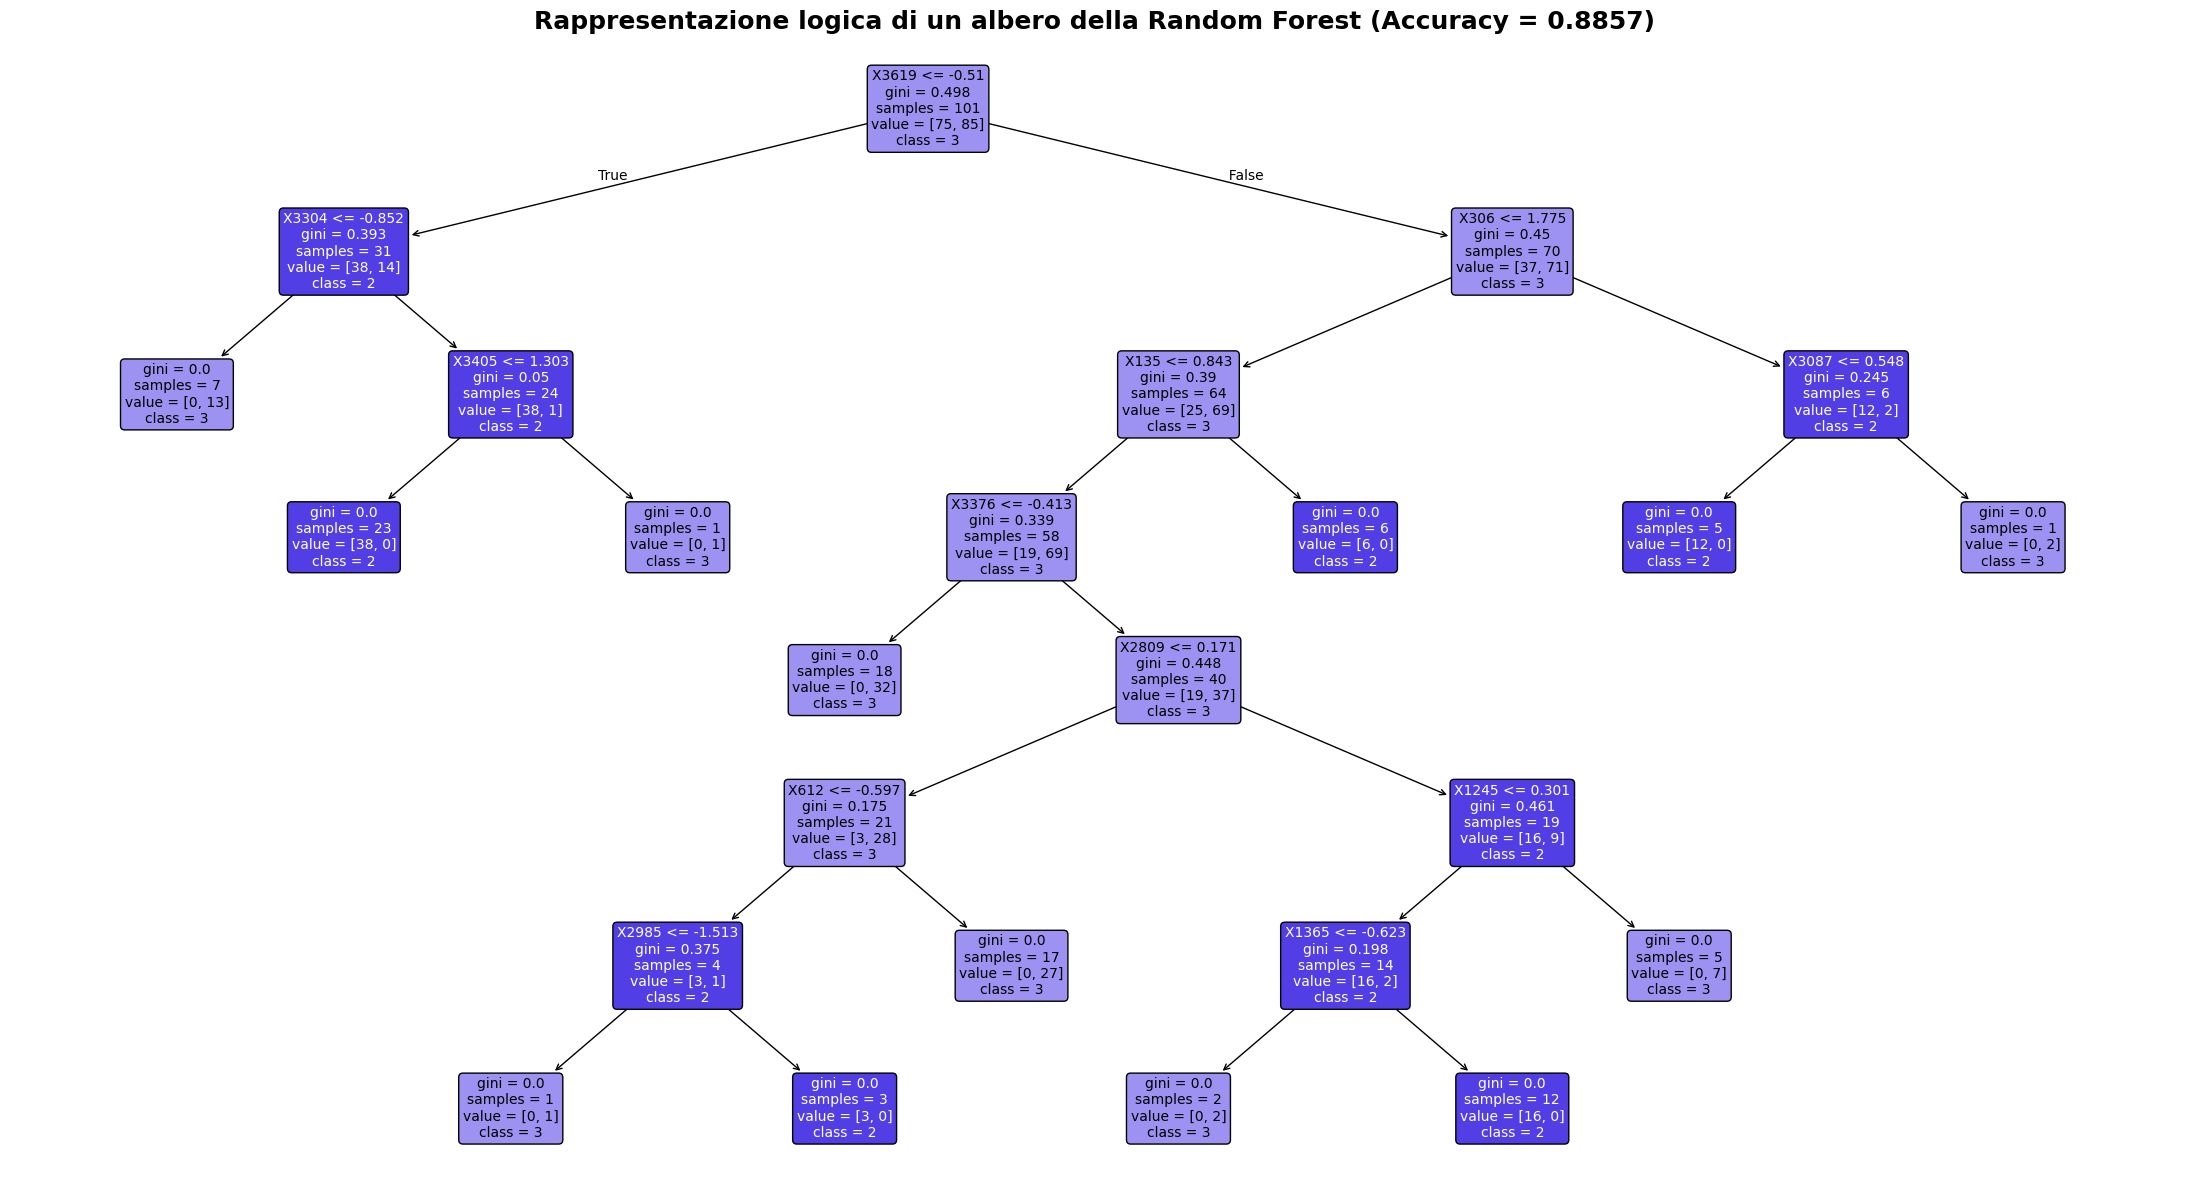

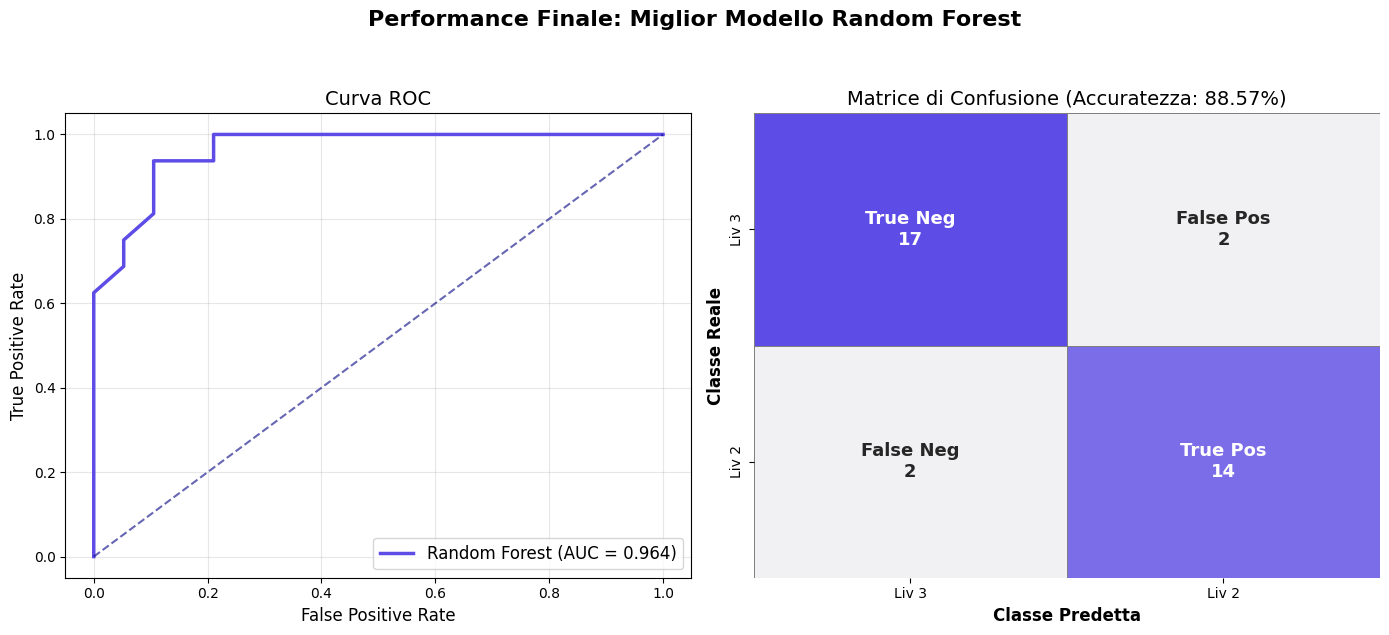

In [19]:
# RAPPRESENTAZIONE GRAFICA DELL'ALBERO RANDOM FOREST (Senza Outliers)
from sklearn.tree import plot_tree

miglior_rf = best_models['Senza Outliers']['RandomForest']

# Calcoliamo l'accuratezza specifica di questo modello sul Test Set
y_pred_rf = miglior_rf.predict(X_test_no)
acc_rf = accuracy_score(y_test_no, y_pred_rf)
# print(f"\nRandom Forest Accuracy: {acc_rf:.4f}")

plt.figure(figsize=(22, 12))
plt.figure(figsize=(22, 12))

# Usiamo la tua definizione originale delle classi
class_names = [str(c) for c in miglior_rf.classes_]

# 1. Salviamo l'output della funzione plot_tree nei 'nodi'
nodi = plot_tree(
    miglior_rf.estimators_[11], 
    feature_names=X_train_no.columns,
    class_names=class_names,
    filled=True,
    rounded=True,
    max_depth=None,
    fontsize=10
)

# 2. TRUCCO ESTETICO: Ricoloriamo i nodi a mano!
colore_liv_2 = "#513ee4"   # Il tuo viola/pervinca scuro (Tumore)
colore_liv_3 = "#9d92f1"   # Un lilla molto chiaro per contrasto (Sano)

for nodo in nodi:
    testo = nodo.get_text()           # Leggiamo il testo dentro il quadratino
    box = nodo.get_bbox_patch()       # Prendiamo il rettangolo colorato
    
    # MODIFICA: Ora cerchiamo la scritta ESATTA 'class = 2' o 'class = 3'
    if 'class = 2' in testo:
        box.set_facecolor(colore_liv_2)
        nodo.set_color("white")       # Testo bianco sul viola scuro
        
    elif 'class = 3' in testo:
        box.set_facecolor(colore_liv_3)
        nodo.set_color("black")       # Testo nero sul lilla chiaro

plt.title(f"Rappresentazione logica di un albero della Random Forest (Accuracy = {acc_rf:.4f})",
          fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

y_score_rf = miglior_rf.predict_proba(X_test_no)[:, 0]

acc_rf = accuracy_score(y_test_no, y_pred_rf)
cm_rf = confusion_matrix(y_test_no, y_pred_rf, labels=[3, 2])

tn, fp, fn, tp = cm_rf.ravel()
tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
tnr = tn / (tn + fp) if (tn + fp) > 0 else 0

fpr_roc, tpr_roc, _ = roc_curve(y_test_no, y_score_rf, pos_label=2)
roc_auc = auc(fpr_roc, tpr_roc)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Performance Finale: Miglior Modello Random Forest', fontsize=16, fontweight='bold', y=1.05)

# SUBPLOT 1: CURVA ROC
ax1 = axes[0]
ax1.plot(fpr_roc, tpr_roc, color='#5e4ce6', linewidth=2.5, label=f"Random Forest (AUC = {roc_auc:.3f})")
ax1.plot([0, 1], [0, 1], color='navy', linestyle='--', alpha=0.6)

ax1.set_title('Curva ROC', fontsize=14)
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.legend(loc="lower right", fontsize=12)
ax1.grid(alpha=0.3)

# SUBPLOT 2: CONFUSION MATRIX
ax2 = axes[1]
# Creiamo le etichette di testo
labels = np.asarray([f"True Neg\n{cm_rf[0,0]}", f"False Pos\n{cm_rf[0,1]}",
                     f"False Neg\n{cm_rf[1,0]}", f"True Pos\n{cm_rf[1,1]}"]).reshape(2,2)

sns.heatmap(cm_rf, annot=labels, fmt='', cmap=mio_viola, cbar=False, ax=ax2,
            xticklabels=['Liv 3', 'Liv 2'], 
            yticklabels=['Liv 3', 'Liv 2'],
            annot_kws={"size": 13, "fontweight": "bold"}, linewidths=0.5, linecolor='grey')

ax2.set_title(f"Matrice di Confusione (Accuratezza: {acc_rf:.2%})", fontsize=14)
ax2.set_ylabel('Classe Reale', fontweight='bold', fontsize=12)
ax2.set_xlabel('Classe Predetta', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

In [20]:
# # In questo modo mi salva il random forest e posso usarlo in app. Rf_model è il best modello. Funziona anche con SVM
# import joblib
# rf_model = best_models['Senza Outliers']['RandomForest']
# joblib.dump(rf_model, 'modello_random_forest.pkl')

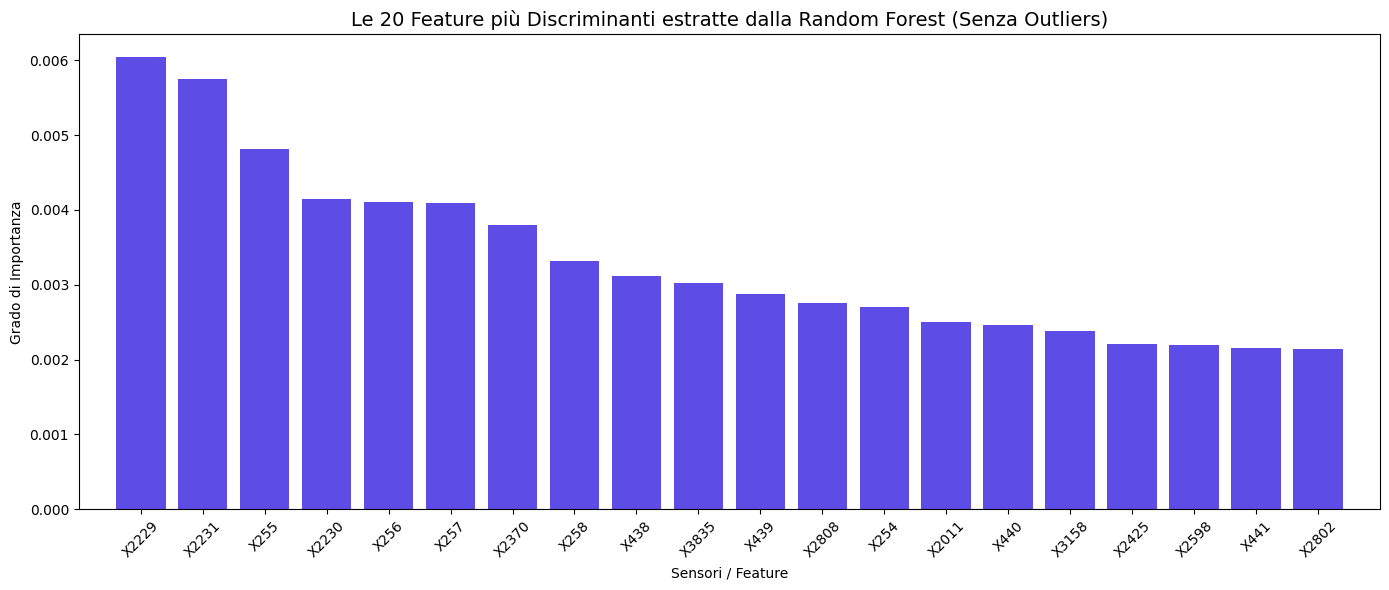

In [21]:
# FEATURE IMPORTANCE RANDOM FOREST (Miglior Modello senza Outliers)
best_rf_no_out = best_models['Senza Outliers']['RandomForest']
importances = best_rf_no_out.feature_importances_
indices = np.argsort(importances)[::-1]

top_k = 20
plt.figure(figsize=(14, 6))
plt.title("Le 20 Feature più Discriminanti estratte dalla Random Forest (Senza Outliers)", fontsize=14)
plt.bar(range(top_k), importances[indices][:top_k], align="center", color='#5e4ce6')
plt.xticks(range(top_k), [X_train_no.columns[i] for i in indices[:top_k]], rotation=45)
plt.ylabel("Grado di Importanza")
plt.xlabel("Sensori / Feature")
plt.xlim([-1, top_k])
plt.tight_layout()
plt.show()

In [22]:
# Test statistico per il confronto dei due migliori modelli

from mlxtend.evaluate import paired_ttest_5x2cv

# Inizializzo i due modelli MIGLIORI
svm_best = svm.SVC(kernel='rbf', C=5.0, gamma='scale') 
rf_best = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=2)

# Eseguo il test 5x2cv
t_stat, p_value = paired_ttest_5x2cv(
    estimator1=svm_best,
    estimator2=rf_best,
    X=X_train_no,       
    y=y_train_no,       
    scoring='roc_auc', # Si può cambiare in 'accuracy'
    random_seed=11   # Per riproducibilità
)

# 3. Stampa e interpretazione risultati
print(f"Statistica t: {t_stat:.3f}")
print(f"P-value: {p_value:.3f}")

alpha = 0.01 

if p_value < alpha:
    print("Risultato: C'è una differenza statisticamente significativa.")
else:
    print("Risultato: NON c'è una differenza statisticamente significativa.")

ModuleNotFoundError: No module named 'mlxtend'

### 3.2 - Ensemble con majority vote
Implementiamo un ensemble con majority vote per cercare di migliorare le prestazioni dei classificatori svm.

In [ ]:
from sklearn.ensemble import VotingClassifier

svm_lineare = svm.SVC(kernel='linear', C=0.001, probability=True, random_state=11)

svm_rbf = svm.SVC(kernel='rbf', C=5, gamma='scale', probability=True, random_state=11)

svm_poly = svm.SVC(kernel='poly', C=5, degree=3, gamma='scale', probability=True, random_state=11)

rf = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=2, random_state=11)

ensemble_modelli = VotingClassifier(
    estimators=[
        ('SVM_Lineare', svm_lineare),
        ('SVM_RBF', svm_rbf),
        ('SVM_Poly', svm_poly),
        ('Random_Forest', rf)
    ],
    voting='hard' 
)

print("Addestramento del modello in Ensemble")
ensemble_modelli.fit(X_train_no, y_train_no)

y_pred_ensemble = ensemble_modelli.predict(X_test_no)

acc_ensemble = accuracy_score(y_test_no, y_pred_ensemble)

print("\n" + "="*50)
print(f" Accuratezza Finale Ensemble: {acc_ensemble:.4f}")
print("="*50)
print("\nReport di Classificazione:")
print(classification_report(y_test_no, y_pred_ensemble))

Addestramento del modello in Ensemble

 Accuratezza Finale Ensemble: 0.8857

Report di Classificazione:
              precision    recall  f1-score   support

           2       0.80      1.00      0.89        16
           3       1.00      0.79      0.88        19

    accuracy                           0.89        35
   macro avg       0.90      0.89      0.89        35
weighted avg       0.91      0.89      0.89        35



L'ensemble con majority vote non sembra migliorare le prestazioni. Questo anche in luce del fatto che, basandosi sulle 'hard' prediction, perde informazioni sul livello di confidenza delle singole predizioni, e quindi il guadagno che si ha nel considerare più modelli, che votano insieme, è controbilanciato dalla perdita di informazioni.

Si potrebbe testare una seconda alternativa usando le 'soft' prediction, oppure cambiare tipo di modello, come ad esempio uno stacking con un AdaBoost.

In [ ]:
# Ripetiamo con 'soft' voting

svm_lineare = svm.SVC(kernel='linear', C=0.001, probability=True, random_state=11)

svm_rbf = svm.SVC(kernel='rbf', C=5, gamma='scale', probability=True, random_state=11)

svm_poly = svm.SVC(kernel='poly', C=5, degree=3, gamma='scale', probability=True, random_state=11)

rf = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=2, random_state=11)

ensemble_modelli = VotingClassifier(
    estimators=[
        ('SVM_Lineare', svm_lineare),
        ('SVM_RBF', svm_rbf),
        ('SVM_Poly', svm_poly),
        ('Random_Forest', rf)
    ],
    voting='soft'
)

print("Addestramento del modello in Ensemble")
ensemble_modelli.fit(X_train_no, y_train_no)

y_pred_ensemble = ensemble_modelli.predict(X_test_no)

acc_ensemble = accuracy_score(y_test_no, y_pred_ensemble)

print("\n" + "="*50)
print(f" Accuratezza Finale Ensemble: {acc_ensemble:.4f}")
print("="*50)
print("\nReport di Classificazione:")
print(classification_report(y_test_no, y_pred_ensemble))

Addestramento del modello in Ensemble

 Accuratezza Finale Ensemble: 0.8857

Report di Classificazione:
              precision    recall  f1-score   support

           2       0.83      0.94      0.88        16
           3       0.94      0.84      0.89        19

    accuracy                           0.89        35
   macro avg       0.89      0.89      0.89        35
weighted avg       0.89      0.89      0.89        35



In [ ]:
# Proviamo ad applicare AdaBoost usando la libreria già pronta
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression # potrei usare questa anziché AdaBoost

# Definiamo i modelli base
base_models = [
    ('svm_lin', svm.SVC(kernel='linear', C=0.001, probability=True)),
    ('svm_poly', svm.SVC(kernel='poly', C=5, degree=3, gamma='scale', probability=True, random_state=11)),
    ('svm_rbf', svm.SVC(kernel='rbf', C=5, probability=True)),
    ('rf', RandomForestClassifier(n_estimators=200, random_state=11))
]

# Definiamo il meta-classificatore
meta_model = AdaBoostClassifier(n_estimators=50)

# Creiamo lo Stacker
stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5 # Fa tutto lui: allena sui fold e predice per il meta-modello
)

# Alleniamo tutto su X_train intero
stacking_model.fit(X_train_no, y_train_no)

# Valutazione
y_pred = stacking_model.predict(X_test_no)
print(f"Accuratezza Stacking: {accuracy_score(y_test_no, y_pred):.4f}")

Accuratezza Stacking: 0.8857


Risultati finali: gli ensemble non sembrano migliorare di molto le prediction singole, e neanche AdaBoost.
Rivedere alla fine Test Statistici per valutare differenze statisticamente significative tra i modelli.

In [ ]:
# ENSEMBLE DEI FOLD CON MAJORITY VOTING CON SVM
from scipy.stats import mode
from sklearn.model_selection import cross_validate

print("\n" + "="*50)
print(" RISULTATI DEL VOTING SVM ")
print("="*50)

for ds_name, (X_tr, y_tr, X_te, y_te) in datasets.items():
    miglior_svm = best_models[ds_name]['SVM']
    
    cv_voting = StratifiedKFold(n_splits=9, shuffle=True, random_state=11)
    cv_results = cross_validate(miglior_svm, X_tr, y_tr, cv=cv_voting, return_estimator=True)
    
    modelli_addestrati = cv_results['estimator']
    
    predizioni_folds = np.array([mod.predict(X_te) for mod in modelli_addestrati])
    
    pred_voting, _ = mode(predizioni_folds, axis=0)
    pred_voting = pred_voting.flatten()
    
    print(f"\n--- Voting SVM: Dataset {ds_name} ---")
    print(f"Accuracy del voting: {accuracy_score(y_te, pred_voting):.4f}")
    print(classification_report(y_te, pred_voting))


 RISULTATI DEL VOTING SVM 

--- Voting SVM: Dataset Con Outliers ---
Accuracy del voting: 0.8750
              precision    recall  f1-score   support

           2       0.86      0.90      0.88        20
           3       0.89      0.85      0.87        20

    accuracy                           0.88        40
   macro avg       0.88      0.88      0.87        40
weighted avg       0.88      0.88      0.87        40


--- Voting SVM: Dataset Senza Outliers ---
Accuracy del voting: 0.8571
              precision    recall  f1-score   support

           2       0.82      0.88      0.85        16
           3       0.89      0.84      0.86        19

    accuracy                           0.86        35
   macro avg       0.86      0.86      0.86        35
weighted avg       0.86      0.86      0.86        35



## 4 - Test rilevanza statistica fra tutti i modelli

Vogliamo ora provare a confrontare statisticamente tutti i modelli rilevanti:

- SVM
- Random Forest
- Ensemble 'hard'
- Ensemble 'soft'
- AdaBoost Stacker

Useremo il Friedman test, collegato al Test di Nemenyi che produrrà una classifica statisticamente significativa dei nostri metodi.

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

models = []

# Inseriamo i modelli nel mio vettore models:
svm_lineare = svm.SVC(kernel='linear', C=0.001, probability=True, random_state=11)
svm_rbf = svm.SVC(kernel='rbf', C=5, gamma='scale', probability=True, random_state=11)
svm_poly = svm.SVC(kernel='poly', C=5, degree=3, gamma='scale', probability=True, random_state=11)
randomforest = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=2, random_state=11)

base_models = [ ('SVM_Lineare', svm_lineare), ('SVM_RBF', svm_rbf),
 ('SVM_Poly', svm_poly), ('Random_Forest', rf) ]

ensemble_hard = VotingClassifier(
    estimators = base_models,
    voting = 'hard'
)
ensemble_soft = VotingClassifier(
    estimators = base_models,
    voting = 'soft'
)
stacking_model = StackingClassifier(
    estimators = base_models,
    final_estimator=AdaBoostClassifier(n_estimators=50),
    cv=5 # Parametro per il training dello Stacking (5fold validation)
)

models.append(svm_lineare)
models.append(svm_rbf)
models.append(svm_poly)
models.append(randomforest)
models.append(ensemble_hard)
models.append(ensemble_soft)
models.append(stacking_model)

# Definiamo i nomi per chiarezza nei risultati
model_names = [
    'SVM_Lin', 'SVM_RBF', 'SVM_Poly', 'RandomForest',
    'Ensemble_Hard', 'Ensemble_Soft', 'Stacking'
]

In [ ]:
# Inizializziamo il contenitore per i risultati (Folds x Modelli)
# Usiamo 9 fold per avere un campione statistico decente
kf = KFold(n_splits=9, shuffle=True, random_state=11)
results_acc = []

print("Inizio Cross-Validation...")

for name, model in zip(model_names, models):
    # Calcoliamo l'Accuracy
    cv_results = cross_val_score(model, X_train_no, y_train_no, cv=kf, scoring='accuracy')
    results_acc.append(cv_results)
    print(f"\t{name}: \tMedia Accuracy = {np.mean(cv_results):.3f}")

# Trasformiamo in un array NumPy (Righe = Fold, Colonne = Modelli)
results_acc = np.array(results_acc).T

# --- TEST DI FRIEDMAN ---
stat, p_global = friedmanchisquare(*results_acc.T)

print("\n--- RISULTATI STATISTICI ---")
print(f"Statistica di Friedman: {stat:.3f}, p-value: {p_global:.5f}")

if p_global < 0.05:
    print("Differenza significativa trovata! Eseguo il test post-hoc di Nemenyi...")

    # Trasformiamo in DataFrame per scikit_posthocs
    df_results = pd.DataFrame(results_acc, columns=model_names)

    # Test di Nemenyi
    # Questo test confronta i rank medi dei modelli
    nemenyi_mat = sp.posthoc_nemenyi_friedman(df_results)

    # Visualizziamo la matrice dei p-value
    print("\nMatrice dei p-value (Nemenyi):")
    print(nemenyi_mat)
else:
    print("Nessuna differenza significativa tra i modelli.")

Inizio Cross-Validation...
	SVM_Lin: 	Media Accuracy = 0.863
	SVM_RBF: 	Media Accuracy = 0.876
	SVM_Poly: 	Media Accuracy = 0.720
	RandomForest: 	Media Accuracy = 0.820
	Ensemble_Hard: 	Media Accuracy = 0.845
	Ensemble_Soft: 	Media Accuracy = 0.889
	Stacking: 	Media Accuracy = 0.864

--- RISULTATI STATISTICI ---
Statistica di Friedman: 21.891, p-value: 0.00127
Differenza significativa trovata! Eseguo il test post-hoc di Nemenyi...

Matrice dei p-value (Nemenyi):
                SVM_Lin   SVM_RBF  SVM_Poly  RandomForest  Ensemble_Hard  \
SVM_Lin        1.000000  0.998975  0.176038      0.821098       0.998975   
SVM_RBF        0.998975  1.000000  0.050343      0.510671       0.958006   
SVM_Poly       0.176038  0.050343  1.000000      0.930955       0.437865   
RandomForest   0.821098  0.510671  0.930955      1.000000       0.976584   
Ensemble_Hard  0.998975  0.958006  0.437865      0.976584       1.000000   
Ensemble_Soft  0.958006  0.998975  0.010548      0.222210       0.761061   
S

Ranking Medi (1 è il migliore):
Ensemble_Soft    2.611111
SVM_RBF          3.111111
Stacking         3.444444
SVM_Lin          3.611111
Ensemble_Hard    4.111111
RandomForest     5.000000
SVM_Poly         6.111111
dtype: float64


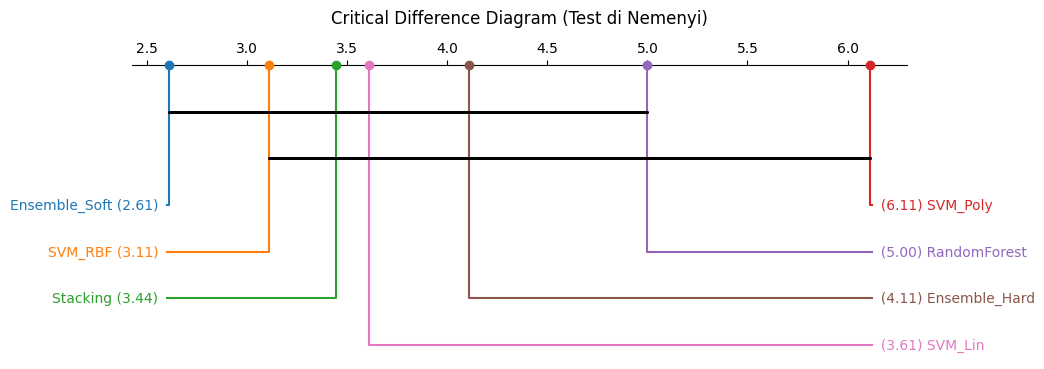

In [ ]:
# Plot con la critical distance

# Creiamo il DataFrame dai risultati (se non lo hai già fatto)
# Ogni colonna è un modello, ogni riga è un fold
df_results = pd.DataFrame(results_acc, columns=model_names)

# Calcoliamo il ranking medio per ogni modello
# rank(ascending=False) perché punteggi più alti (accuracy) significano rank migliori (1, 2...)
average_ranks = df_results.rank(axis=1, ascending=False).mean()

print("Ranking Medi (1 è il migliore):")
print(average_ranks.sort_values())

# Creazione del Critical Difference Diagram
plt.figure(figsize=(10, 4), dpi=100)
plt.title("Critical Difference Diagram (Test di Nemenyi)", pad=20)

# Questa funzione disegna il diagramma di Demšar/Nemenyi
sp.critical_difference_diagram(
    average_ranks,
    nemenyi_mat,
    label_fmt_left='{label} ({rank:.2f})  ',
    label_fmt_right='  ({rank:.2f}) {label}'
)

plt.show()

Rifacciamo tutto ma con la 'roc_auc' come metrica.
Escludo dallo studio la Ensemble_Hard perchè non avendo intervalli di confidenza per le sue classificazioni rischia di "rovinare" i confronti risultando peggiore di tutte le altre.

In [ ]:
# Rifaccio senza ensemble hard
models = []

models.append(svm_lineare)
models.append(svm_rbf)
models.append(svm_poly)
models.append(randomforest)
# models.append(ensemble_hard)
models.append(ensemble_soft)
models.append(stacking_model)

model_names = [
    'SVM_Lin', 'SVM_RBF', 'SVM_Poly', 'RandomForest',
    # 'Ensemble_Hard',
    'Ensemble_Soft', 'Stacking'
]

In [ ]:
# Inizializziamo il contenitore per i risultati (Folds x Modelli)
# Usiamo 9 fold per avere un campione statistico decente
kf = KFold(n_splits=9, shuffle=True, random_state=11)
results_roc_auc = []

print("Inizio Cross-Validation...")

for name, model in zip(model_names, models):
    # Calcoliamo la roc_auc
    cv_results = cross_val_score(model, X_train_no, y_train_no, cv=kf, scoring='roc_auc')
    results_roc_auc.append(cv_results)
    print(f"    {name:<15}: Media Roc_auc = {np.mean(cv_results):.3f}")

# Trasformiamo in un array NumPy (Righe = Fold, Colonne = Modelli)
results_roc_auc = np.array(results_roc_auc).T

# --- TEST DI FRIEDMAN ---
stat, p_global = friedmanchisquare(*results_roc_auc.T)

print("\n--- RISULTATI STATISTICI ---")
print(f"Statistica di Friedman: {stat:.3f}, p-value: {p_global:.5f}")

if p_global < 0.05:
    print("Differenza significativa trovata! Eseguo il test post-hoc di Nemenyi...")

    # Trasformiamo in DataFrame per scikit_posthocs
    df_results = pd.DataFrame(results_roc_auc, columns=model_names)

    # Test di Nemenyi
    # Questo test confronta i rank medi dei modelli
    nemenyi_mat = sp.posthoc_nemenyi_friedman(df_results)

    # Visualizziamo la matrice dei p-value
    print("\nMatrice dei p-value (Nemenyi):")
    print(nemenyi_mat)
else:
    print("Nessuna differenza significativa tra i modelli.")

Inizio Cross-Validation...
    SVM_Lin        : Media Roc_auc = 0.922
    SVM_RBF        : Media Roc_auc = 0.950
    SVM_Poly       : Media Roc_auc = 0.939
    RandomForest   : Media Roc_auc = 0.917
    Ensemble_Soft  : Media Roc_auc = 0.962
    Stacking       : Media Roc_auc = 0.948

--- RISULTATI STATISTICI ---
Statistica di Friedman: 10.455, p-value: 0.06333
Nessuna differenza significativa tra i modelli.


In [ ]:
accuray = []
for name, model in zip(model_names, models):
    model.fit(X_train_no,y_train_no)
    y_pred = model.predict(X_test_no)
    acc = accuracy_score(y_pred,y_test_no)
    print(f"    {name:<15}: Accuracy = {acc:.3f}")
    accuray.append(acc)

    SVM_Lin        : Accuracy = 0.857
    SVM_RBF        : Accuracy = 0.857
    SVM_Poly       : Accuracy = 0.771
    RandomForest   : Accuracy = 0.914
    Ensemble_Soft  : Accuracy = 0.886
    Stacking       : Accuracy = 0.829


## 5 - Ottimizzazione Clinica: Classificazione su finestra Temporale ridotta
Fino a questo momento abbiamo addestrato i modelli sull'intero tracciato EEG di 23.6 secondi (4096 campioni). 
In un contesto clinico reale, ridurre i tempi di acquisizione e di calcolo è fondamentale. Ci siamo quindi posti una domanda pratica: **di quanti secondi di registrazione ha realmente bisogno il nostro miglior modello per individuare l'attività epilettica?**

In questo test, considereremo metà dati dei pazienti (fermandoci ai primi 2048 campioni, pari a circa 11.8 secondi di registrazione) e verificheremo se la nostra Random Forest ottimizzata riesce a mantenere le stesse performance, oppure se la perdita di informazioni compromette la classificazione della zona epilettogena.

In [ ]:
# Analisi su Finestra Temporale Ridotta (0.5 secondi)
print("\n" + "="*70)
print(" TEST: CLASSIFICAZIONE SU MEZZO TEMPO DI REGISTRAZIONE ")
print("="*70)

# 23.6 secondi di registrazione = 4096 campioni.
# Tagliamo i dataset (Senza Outliers) prendendo solo la prima metà del segnale temporale
X_train_half = X_train_no.iloc[:, :2048]
X_test_half = X_test_no.iloc[:, :2048]

# Prendiamo i parametri del miglior modello SVM trovato in precedenza
migliori_parametri_rf = best_models['Senza Outliers']['RandomForest'].get_params()
rf_half = RandomForestClassifier(**migliori_parametri_rf)

# Addestriamo e testiamo sul segnale "dimezzato"
rf_half.fit(X_train_half, y_train_no)
y_pred_half = rf_half.predict(X_test_half)
y_score_half = rf_half.predict_proba(X_test_half)[:, 0]

acc_half = accuracy_score(y_test_no, y_pred_half)
fpr_half, tpr_half, _ = roc_curve(y_test_no, y_score_half, pos_label=2)
auc_half = auc(fpr_half, tpr_half)

print(f"Modello SVM ottimizzato addestrato sulle prime 2048 feature (11.8s):")
print(f" - Accuratezza Test Set : {acc_half:.4f} (rispetto all'analisi completa)")
print(f" - AUC Test Set         : {auc_half:.4f}\n")



 TEST: CLASSIFICAZIONE SU MEZZO TEMPO DI REGISTRAZIONE 
Modello SVM ottimizzato addestrato sulle prime 2048 feature (11.8s):
 - Accuratezza Test Set : 0.8857 (rispetto all'analisi completa)
 - AUC Test Set         : 0.9819



I risultati ottenuti su finestra ridotta sono sorprendenti e hanno un'importante valenza clinica:
* **Accuratezza (0.8857) e AUC (0.9819):** Nonostante il modello abbia a disposizione esattamente la metà delle informazioni temporali (11.8 secondi anziché 23.6), le metriche di valutazione rimangono altissime e pressoché invariate rispetto al modello addestrato sul segnale intero.

**Cosa ci dice questo sull'epilessia?**
Questo risultato dimostra che l'anomalia tipica del Livello 2 (le alterazioni di fondo della zona epilettogena) è una caratteristica stazionaria e pervasiva del segnale cerebrale. Il tessuto non genera anomalie evidenti solo in alcuni istanti casuali, ma presenta frequenze alterate in modo costante. 

Di conseguenza, bastano poco più di 10 secondi di acquisizione EEG per permettere al nostro algoritmo di estrarre i pattern necessari e distinguere con estrema precisione il tracciato epilettico da quello sano (Livello 3).

## 6 - Analisi di Fourier
Isegnali registrati sono potenzialmente periodici; uno studio delle frequenze tramite un'analisi di Fourier si presta ad essere un approccio naturale da seguire. In particolare, l'obiettivo è quello di fare preprocessing del segnale tramite FFT per addestrare successivamente dei modelli sulle frequenze ottenute nella speranza di riconoscere meglio le differenze tra i pazienti di Livello 2 e Livello 3.

In [ ]:
df2_RF = pd.DataFrame(columns=df2.columns) # Real Fourier Transform
df2_IF = pd.DataFrame(columns=df2.columns) # Imag Fourier Transform
df2_Fourier = pd.DataFrame(columns=df2.columns)

for i in range(df2.shape[0]):
    row = np.fft.fft(scale2.iloc[i])
    df2_RF.loc[i] = np.real(row)
    df2_IF.loc[i] = np.imag(row)
    df2_Fourier.loc[i] = np.fft.fftshift(np.abs(row))
df2_Fourier.shape

df3_RF = pd.DataFrame(columns=df3.columns) # Real Fourier Transform
df3_IF = pd.DataFrame(columns=df3.columns) # Imag Fourier Transform
df3_Fourier = pd.DataFrame(columns=df3.columns)

for i in range(df2.shape[0]):
    row = np.fft.fft(scale3.iloc[i])
    df3_RF.loc[i] = np.real(row)
    df3_IF.loc[i] = np.imag(row)
    df3_Fourier.loc[i] = np.fft.fftshift(np.abs(row))

#df3_Fourier.drop(columns = 0)

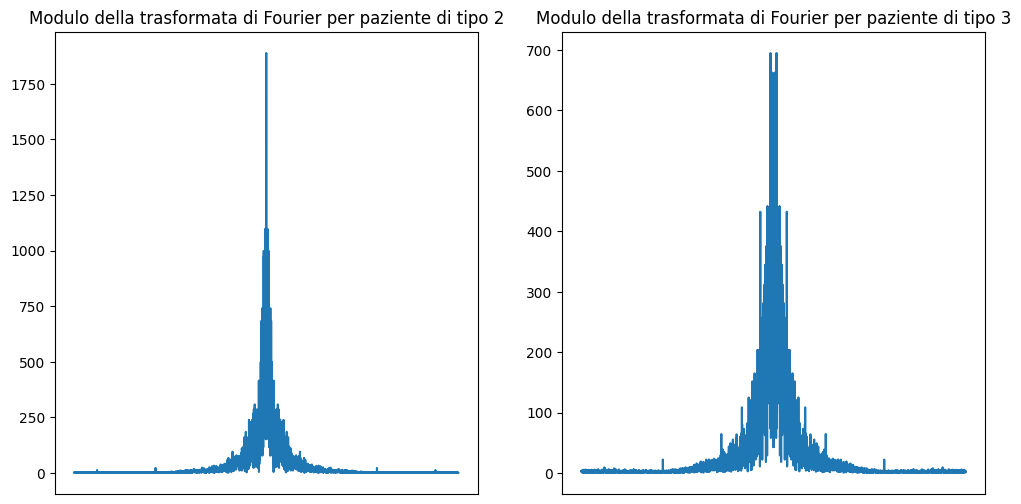

In [ ]:
fig = plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(df2_Fourier.iloc[1])
plt.xticks([])
plt.title('Modulo della trasformata di Fourier per paziente di tipo 2')
plt.subplot(1,2,2)
plt.plot(df3_Fourier.iloc[1])
plt.xticks([])
plt.title('Modulo della trasformata di Fourier per paziente di tipo 3')
plt.show()




In [ ]:
#   Creo il Train Test split per Fourier. All'interno avrò:
#           - aggiungo la colonna y con la label giusta
#           - splitto in train e test
#           - divido in X e Y per train e test

df2_Fourier['y'] = 2
df3_Fourier['y'] = 3

train_FFT= pd.concat([df2_Fourier.iloc[:80], df3_Fourier.iloc[:80]])
test_FFT= pd.concat([df2_Fourier.iloc[80:], df3_Fourier.iloc[80:]])

X_train_FFT = train_FFT.drop(columns=['y'])
y_train_FFT = train_FFT['y']
X_test_FFT = test_FFT.drop(columns=['y'])
y_test_FFT = test_FFT['y']

In [ ]:
# STUDIO PRELIMINARE: Confronto Kernel SVM (Linear, Poly, RBF)
results_plot = {'Con Outliers': {}, 'Senza Outliers': {}}

# for ds_name, (X_train, y_train, X_test, y_test) in datasets.items():
#     # Inizializziamo modelli standard per un'analisi "baseline"
models_pre = {
    'Linear': svm.SVC(kernel='linear', C=0.001, random_state=11),
    'Poly': svm.SVC(kernel='poly', degree=3, C=5, gamma='scale', random_state=11),
    'RBF': svm.SVC(kernel='rbf', C=5, gamma='scale', random_state=11)
}

for model_name, clf in models_pre.items():
    clf.fit(X_train_FFT, y_train_FFT)
    y_pred_FFT = clf.predict(X_test_FFT)
    y_score_FFT = clf.decision_function(X_test_FFT)
    
    acc = accuracy_score(y_test_FFT, y_pred_FFT)
    cm = confusion_matrix(y_test_FFT, y_pred_FFT, labels=[2, 3])
    
    tn, fp, fn, tp = cm.ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    fpr_roc, tpr_roc, _ = roc_curve(y_test_FFT, y_score_FFT, pos_label=3)
    roc_auc = auc(fpr_roc, tpr_roc)
    
    results_plot[ds_name][model_name] = {
        'acc': acc, 'cm': cm, 'tpr': tpr, 'tnr': tnr, 
        'fpr_roc': fpr_roc, 'tpr_roc': tpr_roc, 'auc': roc_auc
    }
print(f"Accuracy = {acc:.3f}")

Accuracy = 0.775


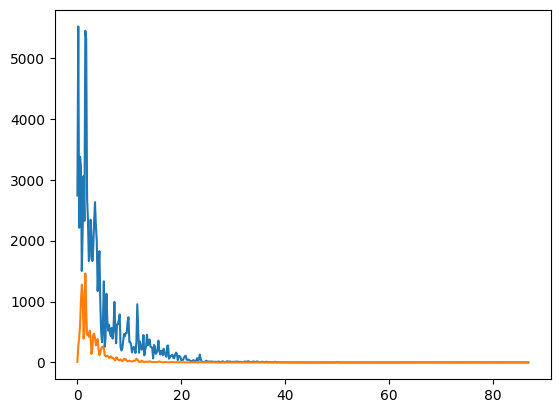

In [ ]:
# STUDIO NEL DOMINIO DELLA FREQUENZA (Analisi Spettrale EEG)
import scipy.signal as signal
from scipy.integrate import simpson
segnale2 = df2_no_out_raw.iloc[11].values
freqs2, psd2 = signal.welch(segnale2, fs=173.61, nperseg=1024)
segnale3 = df3_no_out_raw.iloc[11].values
freqs3, psd3 = signal.welch(segnale3, fs=173.61, nperseg=1024)
plt.plot(freqs2,psd2)
plt.plot(freqs3,psd3)
plt.show()


 ESTRAZIONE DELLE RITMICHE CEREBRALI (Metodo di Welch) 


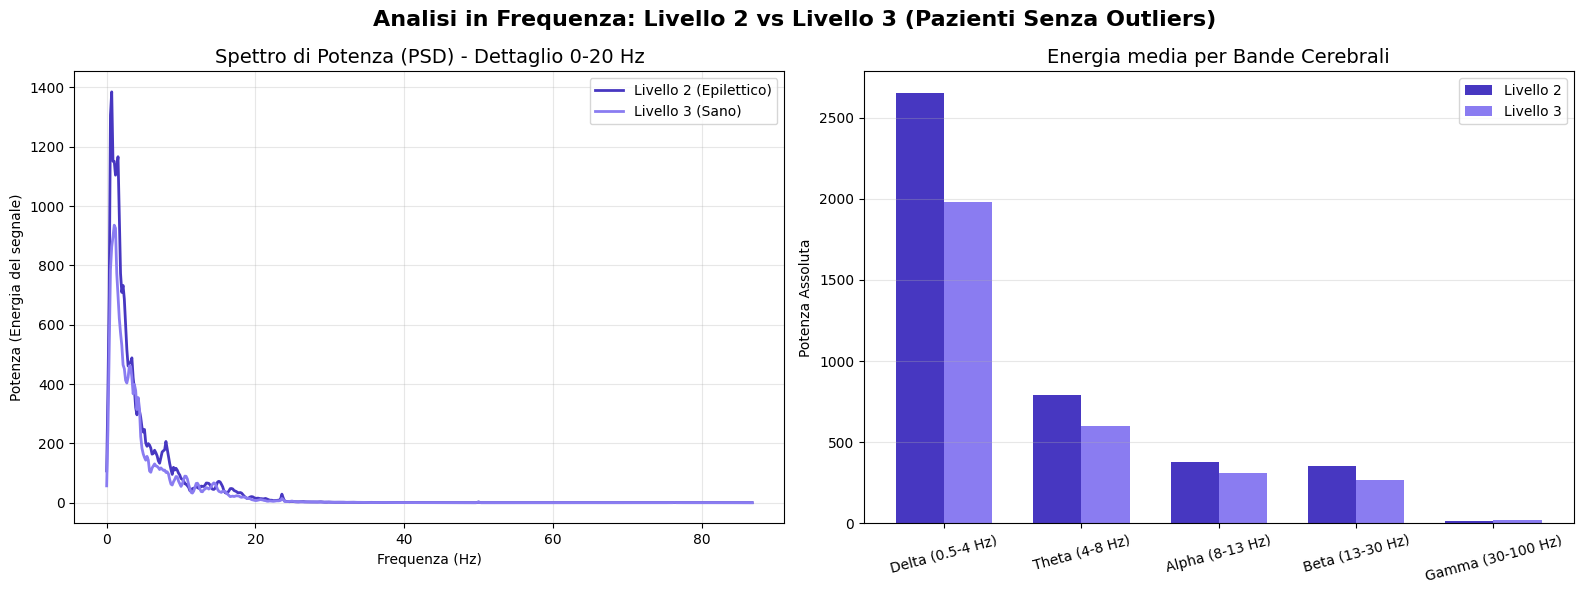

In [ ]:
# STUDIO NEL DOMINIO DELLA FREQUENZA (Analisi Spettrale EEG)
import scipy.signal as signal
from scipy.integrate import simpson

print("\n" + "="*70)
print(" ESTRAZIONE DELLE RITMICHE CEREBRALI (Metodo di Welch) ")
print("="*70)

# Frequenza di campionamento (4096 campioni in 23.6 secondo)
fs = 173.61

# Funzione per calcolare l'energia nelle varie bande cerebrali
def calcola_potenza_bande(dati_classe):
    bande = {'Delta (0.5-4 Hz)': (0.5, 4), 'Theta (4-8 Hz)': (4, 8), 
             'Alpha (8-13 Hz)': (8, 13), 'Beta (13-30 Hz)': (13, 30), 'Gamma (30-100 Hz)': (30, 100)}
    
    potenze_medie = {banda: [] for banda in bande}
    psd_medie = []
    
    # Calcoliamo la PTSD per ogni paziente di questa classe
    for i in range(len(dati_classe)):
        segnale = dati_classe.iloc[i].values
        # Metodo di Welch: calcola le frequenze e la loro potenza
        freqs, psd = signal.welch(segnale, fs, nperseg=1024)
        psd_medie.append(psd)
        
        # Estraiamo l'energia per ogni singola banda
        for nome_banda, (f_min, f_max) in bande.items():
            idx_banda = np.logical_and(freqs >= f_min, freqs <= f_max)
            # Integriamo l'area sotto la curva per avere la potenza totale della banda
            potenza = simpson(psd[idx_banda], freqs[idx_banda])
            potenze_medie[nome_banda].append(potenza)
            
    # Calcoliamo la media su tutti i pazienti
    psd_assoluta = np.mean(psd_medie, axis=0)
    potenze_assolute = {banda: np.mean(valori) for banda, valori in potenze_medie.items()}
    
    return freqs, psd_assoluta, potenze_assolute

# Estrarre i dati grezzi senza outliers (usiamo i dataframe che hai creato prima)
X_livello2 = df2_no_out_raw.drop(columns=['y'])
X_livello3 = df3_no_out_raw.drop(columns=['y'])

# Calcoliamo le frequenze per Livello 2 e Livello 3
freqs, psd2, potenze2 = calcola_potenza_bande(X_livello2)
_, psd3, potenze3 = calcola_potenza_bande(X_livello3)

# ======================================================================
# PLOT DEI RISULTATI IN FREQUENZA
# ======================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analisi in Frequenza: Livello 2 vs Livello 3 (Pazienti Senza Outliers)', fontsize=16, fontweight='bold')

# --- Grafico 1: Densità Spettrale (Come si distribuisce l'energia) ---
ax1.plot(freqs, psd2, label='Livello 2 (Epilettico)', color="#4737c1", lw=2)
ax1.plot(freqs, psd3, label='Livello 3 (Sano)', color='#8a7cf1', lw=2)
# ax1.set_xlim(0, 20) # Guardiamo solo fino a 100 Hz (oltre non c'è EEG utile)
ax1.set_title('Spettro di Potenza (PSD) - Dettaglio 0-20 Hz', fontsize=14)
ax1.set_xlabel('Frequenza (Hz)'); ax1.set_ylabel('Potenza (Energia del segnale)')
ax1.legend(); ax1.grid(alpha=0.3)


# --- Grafico 2: Istogramma delle Bande Cerebrali ---
nomi_bande = list(potenze2.keys())
valori2 = list(potenze2.values())
valori3 = list(potenze3.values())

x = np.arange(len(nomi_bande))
width = 0.35

ax2.bar(x - width/2, valori2, width, label='Livello 2', color='#4737c1')
ax2.bar(x + width/2, valori3, width, label='Livello 3', color='#8a7cf1')
ax2.set_title('Energia media per Bande Cerebrali', fontsize=14)
ax2.set_xticks(x); ax2.set_xticklabels(nomi_bande, rotation=15)
ax2.set_ylabel('Potenza Assoluta'); ax2.legend(); ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4 - Conclusioni
L'analisi del dataset riguardande i segnali EEG per riconoscere la presenza di epilessia nei pazienti ha fatto emergere un dualismo tra i modelli utilizzati. La SVM ha mostrato performance leggermente superiori sul dataset originale (con outliers), mentre la Random Forest ha ottenuto un miglioramento maggiormente della pulizia del dato. Questo si spiega con la natura clinica del segnale EEG: statisticamente, un picco estremo è un outlier, ma clinicamente rappresenta il pattern epilettico. La SVM riesce a sfruttare questi picchi estremi come Support Vectors per tracciare i margini decisionali riguardanti la scelta degli outliers, mentre la Random Forest ne viene 'distratta' andando in overfitting. La pulizia del dato ha quindi rimosso il rumore, costringendo la Random Forest a imparare regole più generalizzabili sulla morfologia dell'onda, aumentandone l'accuratezza sul Test Set.